# DX 603: Project Milestone Two: Modeling and Feature Engineering

### Due: Sunday July 26 @ 11:59PM (with grace period of 2 hours & 1 minute)

### Overview

In Milestone 1, you explored the Zillow dataset, cleaned the data, and developed hypotheses about how preprocessing and feature engineering might improve predictive performance.

In this milestone, you will  develop, evaluate, and refine several machine learning models using those ideas. Rather than simply searching for the best algorithm, you will follow an iterative modeling workflow by:

1. Establishing baseline performance using several regression models.
2. Testing the preprocessing and feature engineering ideas proposed in Milestone 1.
3. Refining the feature set through feature selection.
4. Optimizing model performance through hyperparameter tuning.
5. Comparing the evolution of your models and selecting a final model to evaluate on the held-out test set.

Throughout this milestone, use **repeated 5-fold cross-validation (5 repeats)** to guide your modeling decisions. The held-out test set should be used only once, after all modeling decisions have been completed.




In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import uniform, randint

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold,KFold
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OrdinalEncoder,OneHotEncoder,TargetEncoder,FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest, SelectFromModel
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Load Your Preprocessed Dataset from Milestone 1

In Milestone 1, you cleaned the Zillow dataset by removing unsuitable features, handling missing values, and encoding categorical variables. In this milestone, you will build, compare, and improve several regression models using that prepared dataset.

Begin by returning to your Milestone 1 notebook and rerunning your code through Part 3, where your dataset has been completely cleaned and encoded, but before any experimental feature engineering ideas were evaluated. Save these datasets to use as the starting point for this milestone.

For example, do this at the end of Milestone 1:

```python
X_train.to_csv("X_train.csv", index=False)               # or whatever names you gave these sets
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)
```

Then load them at the beginning of the Milestone 2 notebook:

```python
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_test = pd.read_csv("y_test.csv").squeeze("columns")
```
#### Feature Scaling

Some regression models, such as **Ridge Regression** and **Lasso Regression**, require feature scaling. If you use one of these models, standardize the predictor variables **using only the training data**, then apply the same transformation to the test data.

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

**Notes**

- Ordinary Linear Regression, Decision Trees, Random Forests, and HistGradientBoosting do **not** require feature scaling.
- If you create additional features later in this milestone and are using a scaled model, repeat the scaling step so the new features are transformed consistently.
- Throughout this milestone, use the same training/test split so that all models are evaluated on identical data.

In [2]:
# load the encoded datasets from CSV files which were created in the milestone 1 notebook
X_train = pd.read_csv("X_train_encoded.csv")
X_test = pd.read_csv("X_test_encoded.csv")

y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_test = pd.read_csv("y_test.csv").squeeze("columns")

In [3]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nMissing values:")
print("X_train:", X_train.isna().sum().sum())
print("X_test:", X_test.isna().sum().sum())

print("\nRows match:")
print(len(X_train) == len(y_train))
print(len(X_test) == len(y_test))

X_train shape: (60664, 41)
X_test shape: (15167, 41)
y_train shape: (60664,)
y_test shape: (15167,)

Missing values:
X_train: 0
X_test: 0

Rows match:
True
True


In [4]:
# Scale the features using StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Problem 1: Model Selection and Baselines [6 pts]

### 1.A Coding

Select **three** regression models from the following list and evaluate each one using the cleaned training dataset.

Use the default hyperparameters provided by scikit-learn (except where scaling is required).

Available models:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Decision Tree Regressor
* Bagging Regressor
* Random Forest Regressor
* HistGradientBoostingRegressor

For each of the three models you choose:

* Train using the **training dataset only**.
* Use **Repeated 5-Fold Cross-Validation** (5 repeats).
* Report validation performance:

  * Mean CV MAE
  * Standard Deviation of CV MAE

In [5]:
# Set up RepeatedKFold cross-validation
random_seed = 42
cv = RepeatedKFold(n_splits=5,n_repeats=5,random_state=random_seed)

# Define the models to be evaluated
models = {"Linear Regression": LinearRegression(),
          "Random Forest": RandomForestRegressor(random_state=random_seed),
          "HistGradientBoosting": HistGradientBoostingRegressor(random_state=random_seed)}

# Evaluate each model using cross-validation and store the results
results = []

for model_name, model in models.items():

    # Perform cross-validation and compute the mean absolute error (MAE)
    validation_scores = -cross_val_score(estimator=model,X=X_train, y=y_train,scoring="neg_mean_absolute_error",cv=cv,n_jobs=-1)

    # Fit the model on the entire training set
    model.fit(X_train, y_train)

    # Predictions on the same training set
    train_predictions = model.predict(X_train)

    # Training MAE
    training_mae = mean_absolute_error(y_train, train_predictions)

    mean_validation_mae = validation_scores.mean()
    std_validation_mae = validation_scores.std()

    results.append({
        "Model": model_name,
        "Training MAE": training_mae,
        "Mean Validation MAE": mean_validation_mae,
        "Validation MAE Standard Deviation": std_validation_mae,
        "Train-Validation Gap": mean_validation_mae - training_mae
    })

In [7]:
# Create a DataFrame to display the results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Mean Validation MAE").reset_index(drop=True)
results_df

,Model,Training MAE,Mean Validation MAE,Validation MAE Standard Deviation,Train-Validation Gap
0,Random Forest,69954.159443,188553.663885,2605.799933,118599.504442
1,HistGradientBoosting,184723.037153,191285.873656,3186.693565,6562.836503
2,Linear Regression,229755.151730,230379.352560,2246.227467,624.200831


### 1.B Discussion

Answer the following questions.

#### 1.B.1

Which of your three models achieved the **lowest validation MAE score**?

- Random Forest had the lowest mean cross-validation MAE , it had the best validation performance among the three baseline models.   

#### 1.B.2

Which model produced the **smallest standard deviation** across the repeated cross-validation runs? What does this suggest about its stability?

- Linear Regression produced the smallest standard deviation. This means its results changed the least across the repeated cross-validation runs.   
Therefore, it was the most stable model, even though it did not have the lowest MAE.

#### 1.B.3

Did any model appear to overfit or underfit? Explain your reasoning using the training and cross-validation results.

- Random Forest appeared to overfit because its training error was much lower than its cross-validation error. This means it performed very well on the training data but did not perform as well on unseen data.   
Linear Regression appeared to underfit because both its training and cross-validation errors were high and close to each other. This suggests that the model was too simple to learn the patterns in the data.   
HistGradientBoosting showed the best balance because its training and cross-validation errors were close, while its cross-validation error was still relatively low.

#### 1.B.4

Compare the overall strengths and weaknesses of the three models. Did any model consistently perform better, or were there important tradeoffs between accuracy and stability?

- Random Forest had the best accuracy, but it also showed the most overfitting.   
Linear Regression was the most stable, but it had the highest error and appeared to underfit.   
HistGradientBoosting had almost the same accuracy as Random Forest, but its training and validation results were much closer.   
Therefore, there was a tradeoff between accuracy and stability, and HistGradientBoosting gave the best overall balance.

## Part 2: Evaluate Your Feature Engineering Hypotheses [6 pts]

### 2.A Coding

In **Milestone 1**, you proposed several preprocessing and feature engineering ideas that you believed might improve predictive performance.

Select **at least three** of those ideas and evaluate them.

These may include, for example:

* Creating new features
* Transforming existing features
* Removing features
* Combining features
* Other preprocessing ideas that you proposed in Milestone 1

For each idea:

* Apply the preprocessing or feature engineering to the **training dataset only**.
* Retrain the same three baseline models from **Problem 1** using repeated 5-fold cross-validation (5 repeats). 
* Compare the validation performance (mean CV MAE) and stability (standard deviation of CV MAE) with your original baseline results


> One of the most important things you can learn is that **not every clever idea results in an improvement**--they have to be evaluated by careful experiment.  And negative results are valuable if they are carefully evaluated and discussed!

In [8]:
# create a function to evaluate experiments with different feature sets
def evaluate_experiment(X_experiment, experiment_name):

    experiment_results = []

    for model_name, model in models.items():

        cv_mae_scores = -cross_val_score(estimator=model,X=X_experiment,y=y_train,scoring="neg_mean_absolute_error",cv=cv,n_jobs=-1)

        experiment_results.append({
            "Experiment": experiment_name,
            "Model": model_name,
            "Mean CV MAE": cv_mae_scores.mean(),
            "CV MAE Standard Deviation": cv_mae_scores.std()
        })

    return pd.DataFrame(experiment_results)

In [9]:
# 1- Log Transformation Experiment
X_log = X_train.copy()

X_log["log_finished_sqft"] = np.log1p(X_log["calculatedfinishedsquarefeet"])
X_log["log_lot_sqft"] = np.log1p(X_log["lotsizesquarefeet"])

# Remove the original versions
X_log = X_log.drop(columns=["calculatedfinishedsquarefeet","lotsizesquarefeet"])

print("Baseline shape:", X_train.shape)
print("Log experiment shape:", X_log.shape)

log_results = evaluate_experiment(X_experiment=X_log,experiment_name="Log Area Features")
log_results

Baseline shape: (60664, 41)
Log experiment shape: (60664, 41)


,Experiment,Model,Mean CV MAE,CV MAE Standard Deviation
0,Log Area Features,Linear Regression,242000.930942,2756.392564
1,Log Area Features,Random Forest,188560.039130,2593.107805
2,Log Area Features,HistGradientBoosting,191286.297774,3185.705484


In [10]:
# 2-Ratio Features Experiment
X_ratio = X_train.copy()

total_rooms_temp = X_ratio["bedroomcnt"] + X_ratio["bathroomcnt"]

print("Properties with zero total rooms:",(total_rooms_temp == 0).sum())
print("Properties with zero lot size:",(X_ratio["lotsizesquarefeet"] == 0).sum())

# Replace zero denominators with NaN temporarily
safe_total_rooms = total_rooms_temp.replace(0, np.nan)
safe_lot_size = X_ratio["lotsizesquarefeet"].replace(0, np.nan)

X_ratio["sqft_per_room"] = (X_ratio["calculatedfinishedsquarefeet"]/ safe_total_rooms)
X_ratio["living_lot_ratio"] = (X_ratio["calculatedfinishedsquarefeet"]/ safe_lot_size)

ratio_columns = ["sqft_per_room","living_lot_ratio"]

X_ratio[ratio_columns] = X_ratio[ratio_columns].replace([np.inf, -np.inf], np.nan)

for column in ratio_columns:

    X_ratio[column] = X_ratio[column].fillna(X_ratio[column].median())

print("Missing values in new ratios:",X_ratio[ratio_columns].isna().sum())
print("Baseline shape:", X_train.shape)
print("Ratio experiment shape:", X_ratio.shape)

ratio_results = evaluate_experiment(X_experiment=X_ratio,experiment_name="Ratio Features")
ratio_results

Properties with zero total rooms: 297
Properties with zero lot size: 0
Missing values in new ratios: sqft_per_room       0
living_lot_ratio    0
dtype: int64
Baseline shape: (60664, 41)
Ratio experiment shape: (60664, 43)


,Experiment,Model,Mean CV MAE,CV MAE Standard Deviation
0,Ratio Features,Linear Regression,227408.250455,2278.870671
1,Ratio Features,Random Forest,188910.622464,2607.700703
2,Ratio Features,HistGradientBoosting,192289.668254,3478.240232


In [11]:
# 3- age-quality interaction experiment
X_age_quality = X_train.copy()

X_age_quality["age_quality_interaction"] = (X_age_quality["property_age"]* X_age_quality["buildingqualitytypeid"])

print("Baseline shape:", X_train.shape)
print("Age-quality experiment shape:",X_age_quality.shape)

age_quality_results = evaluate_experiment(X_experiment=X_age_quality,experiment_name="Age-Quality Interaction")
age_quality_results

Baseline shape: (60664, 41)
Age-quality experiment shape: (60664, 42)


,Experiment,Model,Mean CV MAE,CV MAE Standard Deviation
0,Age-Quality Interaction,Linear Regression,230401.230961,2235.670717
1,Age-Quality Interaction,Random Forest,188628.376518,2658.582654
2,Age-Quality Interaction,HistGradientBoosting,191246.590482,2936.123473


In [12]:
# 4- Living Area to Lot Ratio Experiment
X_living_lot = X_train.copy()

safe_lot_size = X_living_lot["lotsizesquarefeet"].mask(X_living_lot["lotsizesquarefeet"] <= 0)

X_living_lot["living_lot_ratio"] = (X_living_lot["calculatedfinishedsquarefeet"]/ safe_lot_size)

X_living_lot["living_lot_ratio"] = (X_living_lot["living_lot_ratio"].replace([np.inf, -np.inf], np.nan))

living_lot_results = evaluate_experiment( X_experiment=X_living_lot,experiment_name="Living Area to Lot Ratio")

living_lot_results

,Experiment,Model,Mean CV MAE,CV MAE Standard Deviation
0,Living Area to Lot Ratio,Linear Regression,230389.534996,2235.013092
1,Living Area to Lot Ratio,Random Forest,188717.579368,2646.506438
2,Living Area to Lot Ratio,HistGradientBoosting,191890.521634,3113.491216


In [13]:
baseline_results = results_df[["Model","Mean Validation MAE","Validation MAE Standard Deviation"]].copy()

baseline_results = baseline_results.rename(columns={"Mean Validation MAE": "Mean CV MAE", "Validation MAE Standard Deviation":"CV MAE Standard Deviation"})

baseline_results.insert(0,"Experiment","Baseline")

baseline_results

,Experiment,Model,Mean CV MAE,CV MAE Standard Deviation
0,Baseline,Random Forest,188553.663885,2605.799933
1,Baseline,HistGradientBoosting,191285.873656,3186.693565
2,Baseline,Linear Regression,230379.352560,2246.227467


In [14]:
all_experiment_results = pd.concat([baseline_results,log_results,ratio_results,age_quality_results, living_lot_results],ignore_index=True)

baseline_mae = (baseline_results.set_index("Model")["Mean CV MAE"])
baseline_std = (baseline_results.set_index("Model")[ "CV MAE Standard Deviation"])

all_experiment_results["MAE Improvement vs Baseline"] = (all_experiment_results.apply(lambda row:baseline_mae[row["Model"]]- row["Mean CV MAE"],axis=1))
all_experiment_results["Stability Improvement vs Baseline"] = (all_experiment_results.apply(lambda row:baseline_std[row["Model"]]- row["CV MAE Standard Deviation"],axis=1))

all_experiment_results = (all_experiment_results.sort_values(by=["Model", "Mean CV MAE"]).reset_index(drop=True))
all_experiment_results

,Experiment,Model,Mean CV MAE,CV MAE Standard Deviation,MAE Improvement vs Baseline,Stability Improvement vs Baseline
0,Age-Quality Interaction,HistGradientBoosting,191246.590482,2936.123473,39.283174,250.570092
1,Baseline,HistGradientBoosting,191285.873656,3186.693565,0.000000,0.000000
2,Log Area Features,HistGradientBoosting,191286.297774,3185.705484,-0.424118,0.988081
3,Living Area to Lot Ratio,HistGradientBoosting,191890.521634,3113.491216,-604.647979,73.202349
4,Ratio Features,HistGradientBoosting,192289.668254,3478.240232,-1003.794599,-291.546667
5,Ratio Features,Linear Regression,227408.250455,2278.870671,2971.102106,-32.643204
6,Baseline,Linear Regression,230379.352560,2246.227467,0.000000,0.000000
7,Living Area to Lot Ratio,Linear Regression,230389.534996,2235.013092,-10.182435,11.214375
8,Age-Quality Interaction,Linear Regression,230401.230961,2235.670717,-21.878401,10.556750
9,Log Area Features,Linear Regression,242000.930942,2756.392564,-11621.578381,-510.165097


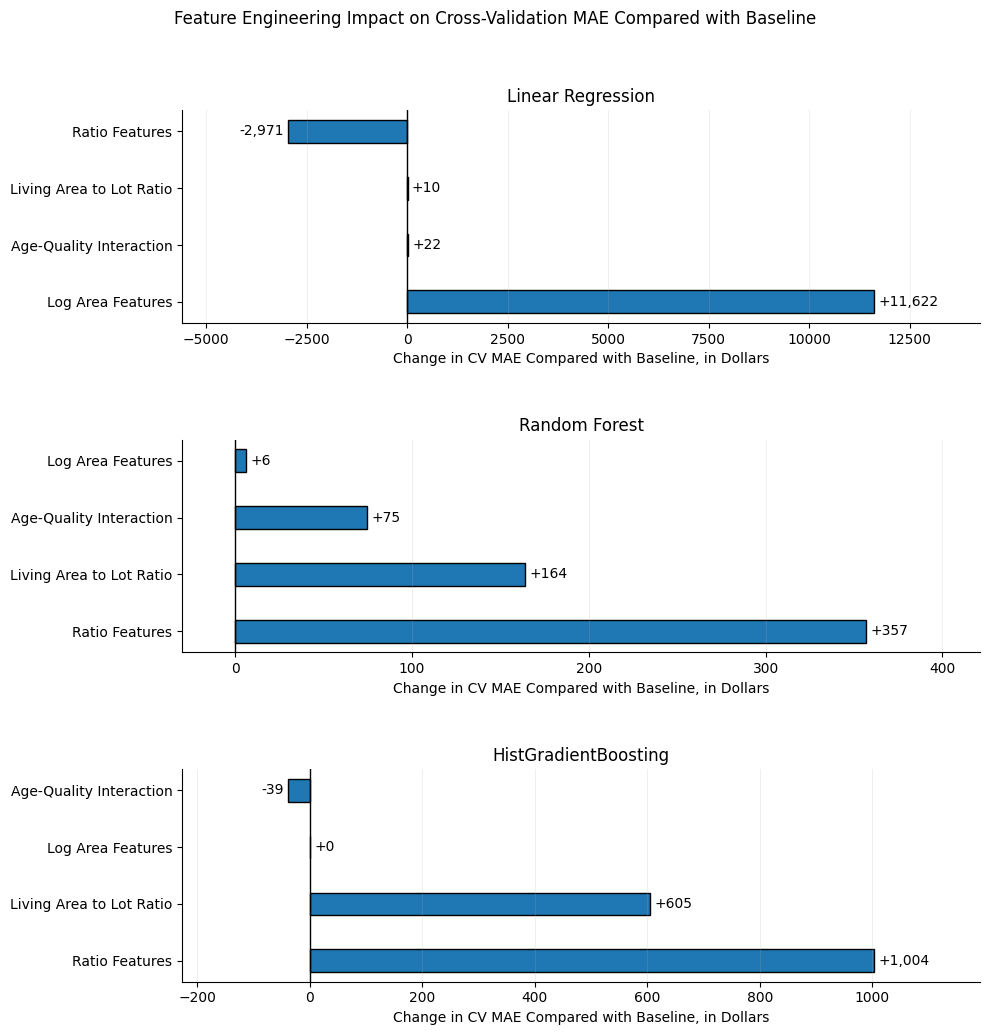

In [ ]:
# Feature Engineering Impact on Cross-Validation MAE Compared with Baseline plot
models = ["Linear Regression","Random Forest","HistGradientBoosting"]
all_experiment_results["Change in MAE vs Baseline"] = -all_experiment_results["MAE Improvement vs Baseline"]

fig, axes = plt.subplots(3,1,figsize=(10, 10))

for ax, model in zip(axes, models):

    model_data = all_experiment_results[(all_experiment_results["Model"] == model) & (all_experiment_results["Experiment"] != "Baseline")].sort_values("Change in MAE vs Baseline", ascending=False)
    bars = ax.barh(model_data["Experiment"], model_data["Change in MAE vs Baseline"], edgecolor="black", height=0.4)

    # Baseline reference
    ax.axvline(0,linewidth=1, color="black")

    # Add values to the bars
    ax.bar_label(bars,labels=[f"{value:+,.0f}" for value in model_data["Change in MAE vs Baseline"]],padding=3)

    ax.set_title(model)
    ax.set_xlabel("Change in CV MAE Compared with Baseline, in Dollars")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.2)
    ax.margins(x=0.18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if model == "Random Forest":
        left, right = ax.get_xlim()
        ax.set_xlim(-30, right)

fig.suptitle("Feature Engineering Impact on Cross-Validation MAE Compared with Baseline", y=1.03)

plt.tight_layout()
plt.subplots_adjust(hspace=0.55)
plt.show()

### 2.B Discussion

Answer the following questions.

#### 2.B.1

Which of your feature engineering ideas produced the largest improvement in validation performance?

- The square-feet-per-room feature produced the largest improvement. It reduced the mean cross-validation MAE of Linear Regression by about $2,971.   
The other feature engineering ideas produced only very small improvements or made performance worse.

#### 2.B.2

Were any of your ideas unsuccessful or did they reduce model performance? Briefly explain.

- Yes. Some ideas were unsuccessful. The log transformation produced the largest decrease in performance, especially for Linear Regression, where the MAE increased by about $11,622 and the model became less stable.   
The living-area-to-lot ratio and the age-quality interaction produced almost no improvement. The ratio features also slightly reduced the performance of the two tree-based models.

#### 2.B.3

Did some models benefit more from feature engineering than others? If so, why do you think this occurred?

- Linear Regression benefited the most from feature engineering. It cannot automatically create ratios or complex relationships from the original features, so the square-feet-per-room feature gave it useful new information.   
Random Forest and HistGradientBoosting benefited much less because tree-based models can already learn many nonlinear relationships and interactions from the original features.   
The age-quality interaction slightly improved the stability of HistGradientBoosting, but its accuracy changed very little.

#### 2.B.4

Which preprocessing or feature engineering changes will you keep for the remainder of the milestone? Briefly justify your decision.

- The effects of feature engineering were different across the three models.   
   - For **Linear Regression**, we will keep the square-feet-per-room feature because it reduced the mean CV MAE by about $2,971.   
   - For **Random Forest**, we will keep the original baseline features because none of the engineered features improved its performance.   
   - For **HistGradientBoosting**, we will keep the age-quality interaction because it slightly reduced the MAE and improved stability across the cross-validation runs. We will not keep the log-transformed area features or the living-area-to-lot ratio because they did not provide meaningful improvements.

## Part 3: Refine the Feature Set [6 pts]

### 3.A Coding

Using your dataset after completing **Part 2** (including any preprocessing and feature engineering changes you decided to keep):

Investigate whether **feature selection** can further improve model performance.

You may use one or more of the following methods:

* Forward Selection (for linear regression models)
* Backward Selection (for linear regression models)
* Feature importance from tree-based models (for decision trees, Random Forests, Bagging, and HistGradientBoosting)
* Another reasonable feature selection method

For each of your three models:

* Select a subset of features using an appropriate feature selection method.
* Retrain the model using only the selected features.
* Evaluate the model using the same repeated cross-validation procedure as before.
* Report the validation performance (the mean and standard deviation of the CV MAE).

> Not every model will necessarily benefit from feature selection. Choose methods that are appropriate for the models you selected. Negative results are valuable if they are carefully evaluated and discussed!

**Linear Regression**

In [14]:
# Linear Regression feature set
X_train_linear = X_train.copy()
X_test_linear = X_test.copy()

total_rooms_train = X_train_linear["bedroomcnt"] + X_train_linear["bathroomcnt"]
total_rooms_test = X_test_linear["bedroomcnt"] + X_test_linear["bathroomcnt"]

X_train_linear["sqft_per_room"] = X_train_linear["calculatedfinishedsquarefeet"] / total_rooms_train.replace(0, np.nan)
X_test_linear["sqft_per_room"] = X_test_linear["calculatedfinishedsquarefeet"] / total_rooms_test.replace(0, np.nan)

sqft_per_room_median = X_train_linear["sqft_per_room"].median()
X_train_linear["sqft_per_room"] = X_train_linear["sqft_per_room"].fillna(sqft_per_room_median)
X_test_linear["sqft_per_room"] = X_test_linear["sqft_per_room"].fillna(sqft_per_room_median)

In [ ]:
# sequential feature selection for linear regression
selection_cv = KFold(n_splits=5, shuffle=True, random_state=42)
linear_model = LinearRegression()

linear_selector = SequentialFeatureSelector(estimator=linear_model, n_features_to_select="auto", tol=None, direction="forward", scoring="neg_mean_absolute_error", cv=selection_cv, n_jobs=-1)
linear_selector.fit(X_train_linear, y_train)

selected_features_linear = X_train_linear.columns[linear_selector.get_support()].tolist()
print("Number of selected features:", len(selected_features_linear))
print("Selected features:", selected_features_linear)

Number of selected features: 21
Selected features: ['bedroomcnt', 'calculatedfinishedsquarefeet', 'hashottuborspa', 'latitude', 'longitude', 'lotsizesquarefeet', 'unitcnt', 'taxdelinquencyflag', 'regionidzip_te', 'fips_6059.0', 'fips_6111.0', 'propertylandusetypeid_247.0', 'propertylandusetypeid_261.0', 'propertylandusetypeid_263.0', 'propertylandusetypeid_275.0', 'heatingorsystemtypeid_1.0', 'heatingorsystemtypeid_18.0', 'heatingorsystemtypeid_2.0', 'heatingorsystemtypeid_24.0', 'heatingorsystemtypeid_7.0', 'sqft_per_room']


In [16]:
# Create new datasets with only the selected features
X_train_linear_selected = X_train_linear[selected_features_linear].copy()
X_test_linear_selected = X_test_linear[selected_features_linear].copy()

print("Before feature selection:", X_train_linear.shape)
print("After feature selection:", X_train_linear_selected.shape)

Before feature selection: (60664, 42)
After feature selection: (60664, 21)


In [17]:
# Evaluate the linear regression model with the selected features using cross-validation
linear_selected_cv_mae = -cross_val_score(estimator=linear_model, X=X_train_linear_selected, y=y_train, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)

linear_selection_results = pd.DataFrame([{
    "Model": "Linear Regression",
    "Feature Selection Method": "Forward Selection",
    "Number of Selected Features": len(selected_features_linear),
    "Mean CV MAE": linear_selected_cv_mae.mean(),
    "CV MAE Standard Deviation": linear_selected_cv_mae.std()
}])

linear_selection_results

,Model,Feature Selection Method,Number of Selected Features,Mean CV MAE,CV MAE Standard Deviation
0,Linear Regression,Forward Selection,21,224878.732632,2486.418157


**Random Forest**

In [18]:
# Random Forest Feature Importance
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

# Train Random Forest to calculate feature importance
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_rf, y_train)

rf_importance_table = pd.DataFrame({
    "Feature": X_train_rf.columns,
    "Importance": np.round(rf_model.feature_importances_, 4)
}).sort_values("Importance", ascending=False).reset_index(drop=True)

rf_importance_table["Cumulative Importance"] = rf_importance_table["Importance"].cumsum()
rf_importance_table

,Feature,Importance,Cumulative Importance
0,calculatedfinishedsquarefeet,0.4001,0.4001
1,regionidzip_te,0.2216,0.6217
2,property_age,0.0585,0.6802
3,bathroomcnt,0.0578,0.7380
4,lotsizesquarefeet,0.0522,0.7902
5,latitude,0.0497,0.8399
6,longitude,0.0479,0.8878
7,regionidcity_te,0.0336,0.9214
8,bedroomcnt,0.0324,0.9538
9,buildingqualitytypeid,0.0143,0.9681


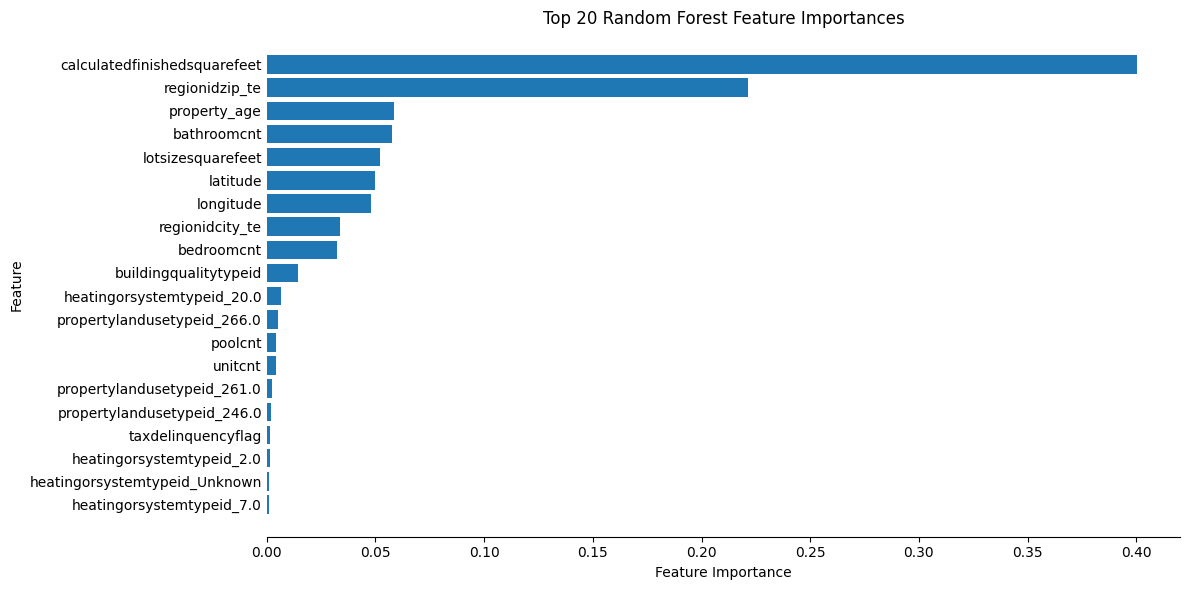

In [19]:
# visualize the top 20 features based on importance
top_20_rf_importance = rf_importance_table.head(20).sort_values("Importance")

plt.figure(figsize=(12, 6))
plt.barh(top_20_rf_importance["Feature"],top_20_rf_importance["Importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.tick_params(axis='y', length=0) 
 
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

In [20]:
# Select the top 20 features that cover about 99.7% of the total importance
best_k_rf = 20

selected_features_rf = rf_importance_table.head(best_k_rf)["Feature"].tolist()

X_train_rf_selected = X_train_rf[selected_features_rf].copy()
X_test_rf_selected = X_test_rf[selected_features_rf].copy()

print("Number of selected features:", len(selected_features_rf))
print("Selected features:", selected_features_rf)
print("Before feature selection:", X_train_rf.shape)
print("After feature selection:", X_train_rf_selected.shape)

Number of selected features: 20
Selected features: ['calculatedfinishedsquarefeet', 'regionidzip_te', 'property_age', 'bathroomcnt', 'lotsizesquarefeet', 'latitude', 'longitude', 'regionidcity_te', 'bedroomcnt', 'buildingqualitytypeid', 'heatingorsystemtypeid_20.0', 'propertylandusetypeid_266.0', 'poolcnt', 'unitcnt', 'propertylandusetypeid_261.0', 'propertylandusetypeid_246.0', 'taxdelinquencyflag', 'heatingorsystemtypeid_2.0', 'heatingorsystemtypeid_7.0', 'heatingorsystemtypeid_Unknown']
Before feature selection: (60664, 41)
After feature selection: (60664, 20)


In [21]:
# Evaluate Random Forest with the selected features using repeated cross-validatio
rf_selected_cv_mae = -cross_val_score(estimator=rf_model,X=X_train_rf_selected,y=y_train,scoring="neg_mean_absolute_error",cv=cv,n_jobs=-1)

rf_selection_results = pd.DataFrame([{
    "Model": "Random Forest",
    "Feature Selection Method": "Top 20 Feature Importance",
    "Number of Selected Features": len(selected_features_rf),
    "Mean CV MAE": rf_selected_cv_mae.mean(),
    "CV MAE Standard Deviation": rf_selected_cv_mae.std()
}])

rf_selection_results

,Model,Feature Selection Method,Number of Selected Features,Mean CV MAE,CV MAE Standard Deviation
0,Random Forest,Top 20 Feature Importance,20,188559.739853,2672.631


**HistGradientBoosting**

In [22]:
# HistGradientBoosting feature set
X_train_hgb = X_train.copy()
X_test_hgb = X_test.copy()

X_train_hgb["age_quality_interaction"] = X_train_hgb["property_age"] * X_train_hgb["buildingqualitytypeid"]
X_test_hgb["age_quality_interaction"] = X_test_hgb["property_age"] * X_test_hgb["buildingqualitytypeid"]

In [ ]:
# Create a temporary validation set for permutation importance
X_hgb_selection_train, X_hgb_selection_valid, y_hgb_selection_train, y_hgb_selection_valid = train_test_split(X_train_hgb,y_train,test_size=0.2,random_state=42)

# Train HistGradientBoosting for permutation importance
hgb_model = HistGradientBoostingRegressor(random_state=42)
hgb_model.fit(X_hgb_selection_train, y_hgb_selection_train)

# Calculate permutation importance on the validation set
hgb_permutation_results = permutation_importance(
    estimator=hgb_model,
    X=X_hgb_selection_valid,
    y=y_hgb_selection_valid,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [24]:
# Create the permutation importance table
hgb_permutation_table = pd.DataFrame({
    "Feature": X_hgb_selection_valid.columns,
    "Importance Mean": hgb_permutation_results.importances_mean,
    "Importance Standard Deviation": hgb_permutation_results.importances_std
}).sort_values("Importance Mean", ascending=False).reset_index(drop=True)

hgb_permutation_table

,Feature,Importance Mean,Importance Standard Deviation
0,calculatedfinishedsquarefeet,80806.354764,1293.069307
1,regionidzip_te,55676.865358,636.827475
2,property_age,13799.761053,350.927653
3,latitude,10564.610896,816.730184
4,longitude,8168.765134,569.304916
5,age_quality_interaction,6045.983731,250.384075
6,bathroomcnt,4603.613921,694.375980
7,buildingqualitytypeid,3328.094037,208.669949
8,bedroomcnt,1899.586644,158.170554
9,lotsizesquarefeet,1778.188938,312.102330


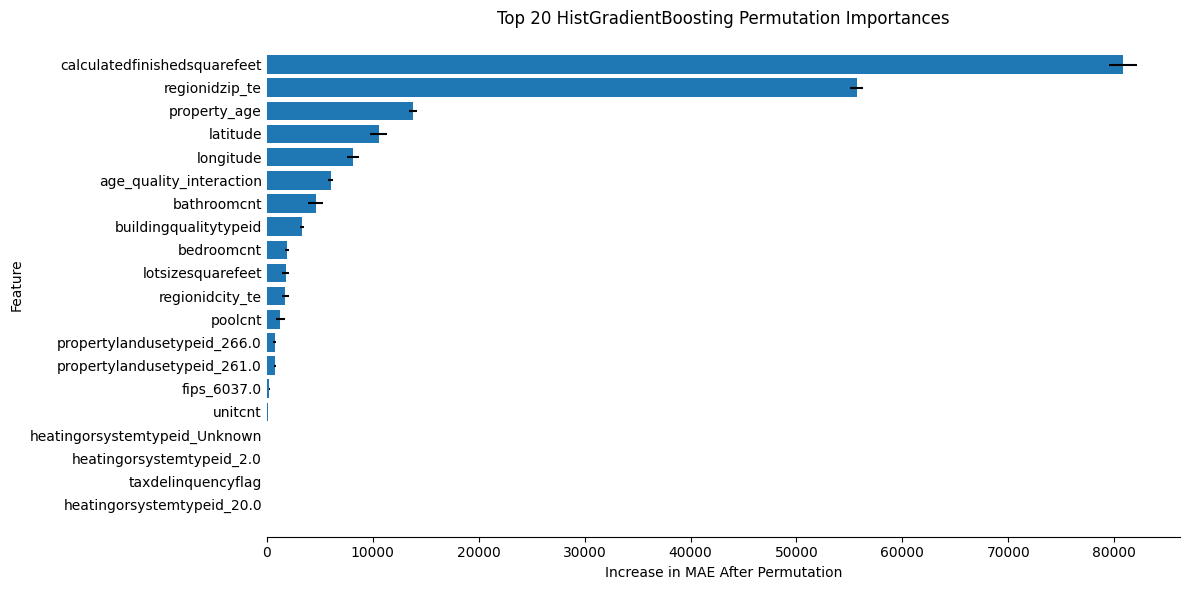

In [25]:
# Plot the top 20 permutation importances
hgb_importance_plot = hgb_permutation_table.head(20).sort_values("Importance Mean")

plt.figure(figsize=(12, 6))
plt.barh(hgb_importance_plot["Feature"],hgb_importance_plot["Importance Mean"],xerr=hgb_importance_plot["Importance Standard Deviation"])

plt.xlabel("Increase in MAE After Permutation")
plt.ylabel("Feature")
plt.title("Top 20 HistGradientBoosting Permutation Importances")
plt.tick_params(axis='y', length=0)
plt.xlim(left=0) 
 
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

In [26]:
# Select features with clear permutation importance
selected_features_hgb = hgb_permutation_table.head(20)["Feature"].tolist()

X_train_hgb_selected = X_train_hgb[selected_features_hgb].copy()
X_test_hgb_selected = X_test_hgb[selected_features_hgb].copy()

print("Number of selected features:", len(selected_features_hgb))
print("Selected features:", selected_features_hgb)
print("Before feature selection:", X_train_hgb.shape)
print("After feature selection:", X_train_hgb_selected.shape)

Number of selected features: 20
Selected features: ['calculatedfinishedsquarefeet', 'regionidzip_te', 'property_age', 'latitude', 'longitude', 'age_quality_interaction', 'bathroomcnt', 'buildingqualitytypeid', 'bedroomcnt', 'lotsizesquarefeet', 'regionidcity_te', 'poolcnt', 'propertylandusetypeid_266.0', 'propertylandusetypeid_261.0', 'fips_6037.0', 'unitcnt', 'heatingorsystemtypeid_Unknown', 'heatingorsystemtypeid_2.0', 'taxdelinquencyflag', 'heatingorsystemtypeid_20.0']
Before feature selection: (60664, 42)
After feature selection: (60664, 20)


In [27]:
# Evaluate HistGradientBoosting with selected features
hgb_selected_cv_mae = -cross_val_score(estimator=HistGradientBoostingRegressor(random_state=42),X=X_train_hgb_selected,y=y_train,scoring="neg_mean_absolute_error",cv=cv,n_jobs=-1)

hgb_selection_results = pd.DataFrame([{
    "Model": "HistGradientBoosting",
    "Feature Selection Method": "Permutation Importance",
    "Number of Selected Features": len(selected_features_hgb),
    "Mean CV MAE": hgb_selected_cv_mae.mean(),
    "CV MAE Standard Deviation": hgb_selected_cv_mae.std()
}])

hgb_selection_results

,Model,Feature Selection Method,Number of Selected Features,Mean CV MAE,CV MAE Standard Deviation
0,HistGradientBoosting,Permutation Importance,20,191511.598695,2829.547944


### 3.B Discussion

#### 3.B.1

Did feature selection improve the validation performance of any of your models?

- Yes. Feature selection improved the validation performance of Linear Regression.  
For Random Forest and HistGradientBoosting, the validation performance stayed nearly the same. Therefore, the clearest improvement was seen in Linear Regression.

#### 3.B.2

Were there features that were consistently retained (or consistently removed) across multiple models?

- Yes. Several property and location features were retained across multiple models.   
These included finished square footage, property age, bedroom and bathroom counts, lot size, building quality, and location features such as zip code, city, latitude, and longitude.   
Many rare property land use and heating system categories were removed because they had very low or zero importance.

#### 3.B.3

Were any of your engineered features selected as important? If so, what does this suggest about the hypotheses you developed in Milestone 1?

- Yes. The engineered `sqft_per_room` feature was retained for Linear Regression and helped improve its validation performance. This supports our Milestone 1 idea that combining finished square footage with room counts could describe the amount of living space per room better than using these features separately.

- The `age_quality_interaction` feature was also important for HistGradientBoosting. We did not specifically propose this feature in Milestone 1, but we noted that multiplying related features could be tested later. Its importance suggests that the effect of property age may depend on the quality of the building.

#### 3.B.4

After feature selection, did simpler models perform as well as—or better than—the models using the full feature set? Briefly discuss any tradeoffs you observed between model complexity and predictive performance.

- The simpler models performed as well as, or better than, the models using all features. Linear Regression improved after feature selection, which suggests that some of the removed features may have added unnecessary noise or made the linear model harder to fit.

- For Random Forest and HistGradientBoosting, validation performance stayed nearly the same after many features were removed. This suggests that the removed features added little useful information or repeated information already provided by stronger features.

- The main tradeoff is that using fewer features can reduce training time, prediction time, and memory use, while also making the models easier to understand. However, removing too many features could also remove useful information and reduce prediction performance. In our results, we reduced model complexity while keeping similar or better validation performance.

## Part 4: Tune Your Models [8 pts]

### 4.A Coding

Using the three models developed in **Part 3** (including your final preprocessing, feature engineering, and feature selection decisions):

Investigate whether **hyperparameter tuning** can further improve model performance.

For each of your three models:

* Select one or more important hyperparameters to tune.
* Use one or more appropriate tuning methods. Consider first using validation curves (`sweep_parameter`) to identify a promising region or performance plateau, followed by a focused search using methods such as:

    * GridSearchCV
    * RandomizedSearchCV
    * Another reasonable hyperparameter search method

* Choose hyperparameter values based on the validation results. If several nearby values produce similar validation performance (a performance plateau), prefer **values near the beginning of the plateau,** since they often produce simpler models with nearly identical predictive performance.
* Retrain the model using those hyperparameters.
* Evaluate the tuned model using repeated 5-fold cross-validation (5 repeats). 
* Report the validation performance (**mean** and **standard deviation** of the CV MAE).


In [31]:
# Run the model for testing and returning metrics.
def run_model(model, 
              X_train, y_train, 
              n_repeats=5, 
              n_jobs=-1, 
              **model_params
             ):

    # Instantiate the model if a class is provided
    if isinstance(model, type):
        model = model(**model_params)
    else:                                    
        model.set_params(**model_params)    

    # Use negative MAE for cross-validation (since sklearn minimizes loss)
    neg_mae_scores = cross_val_score(
        model, 
        X_train, y_train,
        scoring='neg_mean_absolute_error',
        cv=RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=random_seed), 
        n_jobs=n_jobs
    )
    
    mean_cv_mae = -np.mean(neg_mae_scores)
    std_cv_mae  =  np.std(neg_mae_scores)
    
    # Fit the model on the full training set
    model.fit(X_train, y_train)
    
    # Compute training MAE
    train_preds = model.predict(X_train)
    train_mae   = mean_absolute_error(y_train, train_preds)
    
    return mean_cv_mae, std_cv_mae, train_mae

In [ ]:
def sweep_parameter(model,
                    Parameters,
                    param,
                    parameter_list,
                    X_train          = X_train_hgb_selected,              
                    y_train          = y_train,
                    verbose          = True,
                    show_mae         = True,
                    show_std         = True, # check std dev on last model and best model
                    n_iter_no_change = None,
                    delta            = 0.001,
                    n_jobs           = -1,
                    n_repeats        = 5
                   ):
    

    start = time.time()
    Parameters = Parameters.copy()  # Avoid modifying the original dictionary
    
    cv_maes, std_cvs, train_maes = [], [], []
    no_improve_count = 0
    best_mae = float('inf')
    
    # Run over each value in parameter_list
    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        Parameters[param] = p
        P_temp = Parameters.copy()
        P_temp.pop('MAE_found', None)  
        P_temp.pop('STD_found', None)  
        
        cv_mae, std_cv, train_mae = run_model(
            model=model,
            X_train=X_train, y_train=y_train,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            **P_temp
        )
        cv_maes.append(cv_mae)
        std_cvs.append(std_cv)
        train_maes.append(train_mae)
        
        if cv_mae < best_mae - delta:
            best_mae = cv_mae
            no_improve_count = 0
        else:
            no_improve_count += 1
        
        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break

    # Identify best parameter
    min_cv_mae = min(cv_maes)
    min_index = cv_maes.index(min_cv_mae)
    best_param = parameter_list[min_index]
    Parameters[param] = best_param
    Parameters['MAE_found'] = min_cv_mae
    
    # Adding standard deviation to output - get standard deviation for min CV MAE
    min_std = std_cvs[min_index]
    Parameters['STD_found'] = min_std

    # ---------- Plotting section ----------
    if verbose:
        partial_param_list = parameter_list[:len(cv_maes)]

        is_boolean = all(isinstance(val, bool) for val in partial_param_list)
        if is_boolean:
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(val) for val in partial_param_list]
        else:
            x_vals = partial_param_list
            x_labels = partial_param_list

        error_name = 'MAE'

        # Create appropriate number of subplots
        if show_std:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
        else:
            fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))

        ax1.set_title(f"{error_name} vs {param}")
        if show_mae:
            ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

        ax1.plot(x_vals,
                 cv_maes,
                 marker='.', label="CV MAE", color='blue')
        ax1.plot(x_vals,
                 train_maes,
                 marker='.', label="Train MAE", color='green')
        ax1.scatter([x_vals[min_index]],
                    [min_cv_mae],
                    marker='x', label="Best CV MAE", color='red')

        ax1.set_ylabel(error_name)
        ax1.legend()
        ax1.grid()

        # Optional Std Dev Plot
        if show_std:
            ax2.set_title(f"CV Standard Deviation vs {param}")
            ax2.plot(x_vals, std_cvs, marker='.', label="CV MAE Std", color='blue')
            ax2.set_xlabel(param)
            ax2.set_ylabel("Standard Deviation")
            ax2.legend()
            ax2.grid(alpha=0.5)

            if is_boolean:
                ax2.set_xticks(x_vals)
                ax2.set_xticklabels(x_labels)
        else:
            ax1.set_xlabel(param)
            if is_boolean:
                ax1.set_xticks(x_vals)
                ax1.set_xticklabels(x_labels)

        plt.tight_layout()
        plt.show()

        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

    return Parameters


### **Random Forest Regressor Tuning**

In [36]:
Default_Parameters_RF = {"n_estimators": 200,"random_state": 42}

In [37]:
Params_RF = Default_Parameters_RF.copy()

Sweeping max_depth: 100%|██████████| 12/12 [41:31<00:00, 207.65s/it]


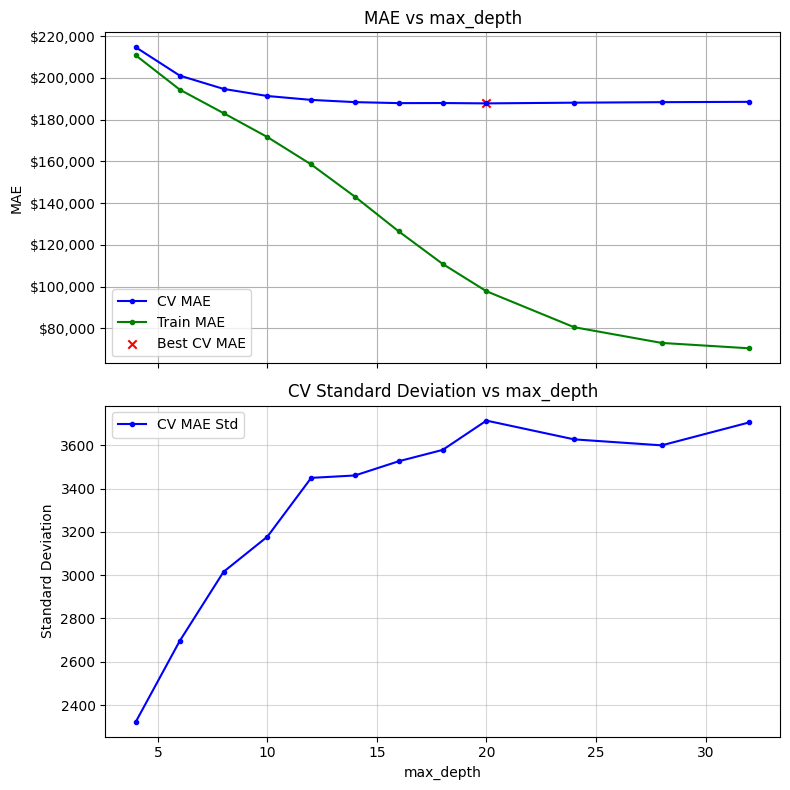

Execution Time: 00:41:31


{'n_estimators': 200,
 'random_state': 42,
 'max_depth': 20,
 'MAE_found': np.float64(187817.79410066776),
 'STD_found': np.float64(3713.8318589224727)}

In [39]:
# Fine-tuning max_depth 
Params_RF = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=Params_RF,
    param="max_depth",
    parameter_list=[4, 6, 8, 10, 12, 14, 16, 18, 20, 24, 28, 32],
    X_train=X_train_rf_selected,
    y_train=y_train,
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)
Params_RF

Sweeping min_samples_leaf: 100%|██████████| 11/11 [38:19<00:00, 209.02s/it]


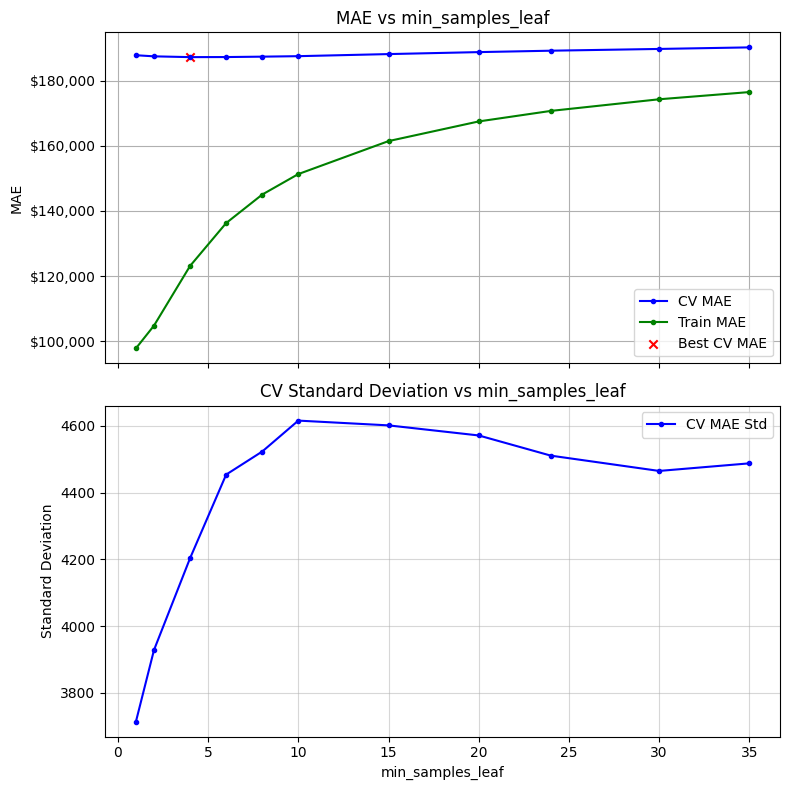

Execution Time: 00:38:19


{'n_estimators': 200,
 'random_state': 42,
 'max_depth': 20,
 'MAE_found': np.float64(187235.46142483247),
 'STD_found': np.float64(4203.497254844662),
 'min_samples_leaf': 4}

In [40]:
# Fine-tuning min_samples_leaf 
min_samples_leaf_values = [1, 2, 4, 6, 8, 10, 15, 20, 24, 30, 35]

Params_RF = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=Params_RF,
    param="min_samples_leaf",
    parameter_list=min_samples_leaf_values,
    X_train=X_train_rf_selected,
    y_train=y_train,
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)

Params_RF

Sweeping max_features: 100%|██████████| 8/8 [19:58<00:00, 149.83s/it]


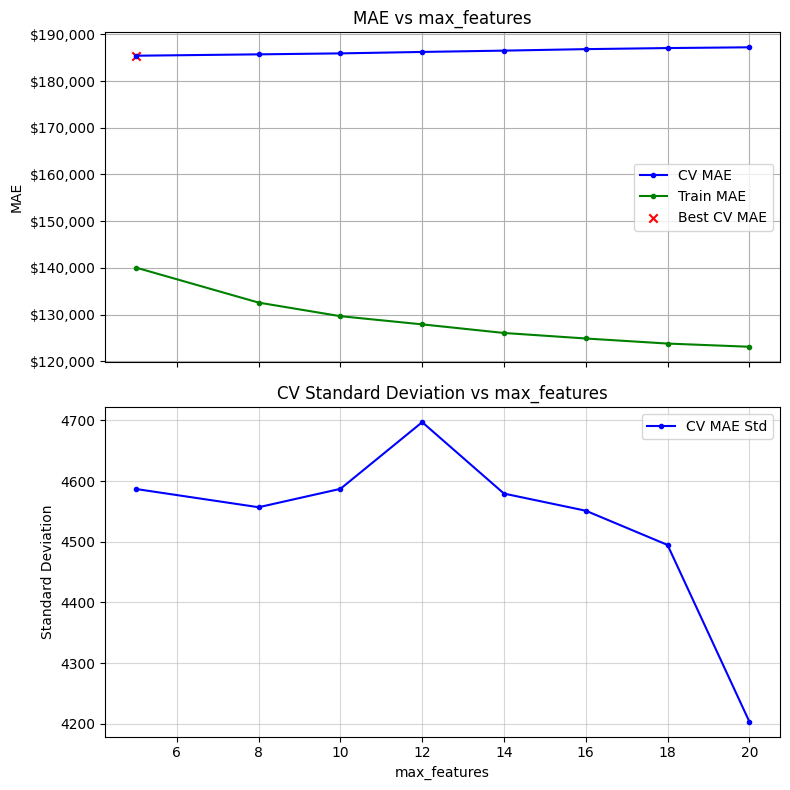

Execution Time: 00:19:58


{'n_estimators': 200,
 'random_state': 42,
 'max_depth': 20,
 'MAE_found': np.float64(185433.2711794068),
 'STD_found': np.float64(4586.828222027592),
 'min_samples_leaf': 4,
 'max_features': 5}

In [41]:
# Fine-tuning max_features
max_features_values = [5, 8, 10, 12, 14, 16, 18, 20]

Params_RF = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=Params_RF,
    param="max_features",
    parameter_list=max_features_values,
    X_train=X_train_rf_selected,
    y_train=y_train,
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)

Params_RF

Sweeping min_samples_split: 100%|██████████| 10/10 [11:18<00:00, 67.86s/it]


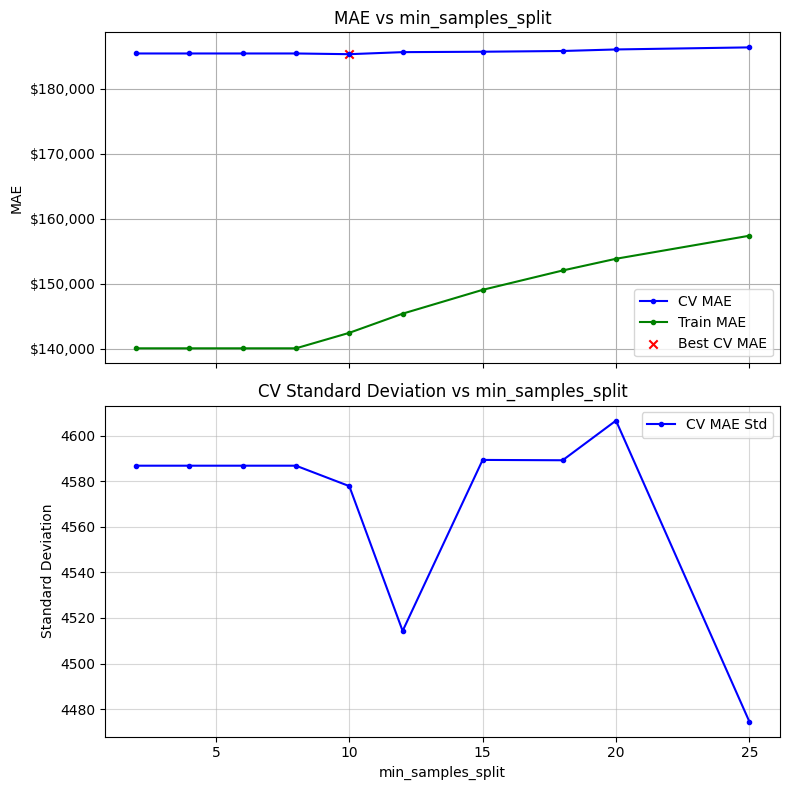

Execution Time: 00:11:18


{'n_estimators': 200,
 'random_state': 42,
 'max_depth': 20,
 'MAE_found': np.float64(185323.44712789825),
 'STD_found': np.float64(4577.863326289493),
 'min_samples_leaf': 4,
 'max_features': 5,
 'min_samples_split': 10}

In [42]:
# Fine-tuning min_samples_split
min_samples_split_values = [2, 4, 6, 8, 10, 12, 15, 18, 20, 25]

Params_RF = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=Params_RF,
    param="min_samples_split",
    parameter_list=min_samples_split_values,
    X_train=X_train_rf_selected,
    y_train=y_train,
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)

Params_RF

Sweeping n_estimators: 100%|██████████| 8/8 [23:39<00:00, 177.42s/it]


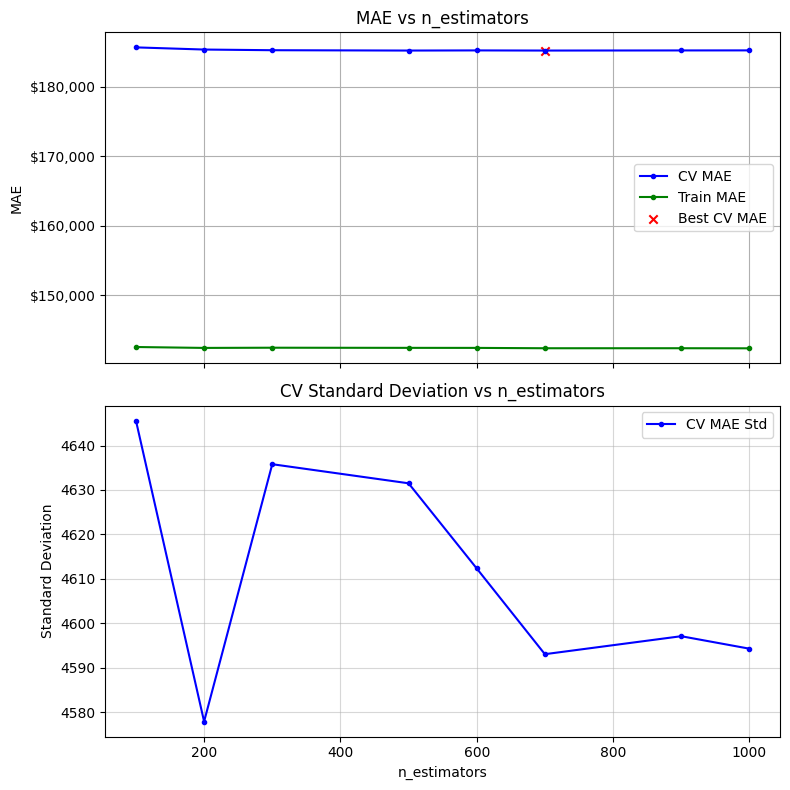

Execution Time: 00:23:39


{'n_estimators': 700,
 'random_state': 42,
 'max_depth': 20,
 'MAE_found': np.float64(185178.83036344877),
 'STD_found': np.float64(4593.028547601803),
 'min_samples_leaf': 4,
 'max_features': 5,
 'min_samples_split': 10}

In [43]:
# Fine-tuning n_estimators
n_estimators_values = [100, 200, 300, 500, 600, 700, 900, 1000]

Params_RF = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=Params_RF,
    param="n_estimators",
    parameter_list=n_estimators_values,
    X_train=X_train_rf_selected,
    y_train=y_train,
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)

Params_RF

Sweeping max_depth: 100%|██████████| 5/5 [32:36<00:00, 391.38s/it]


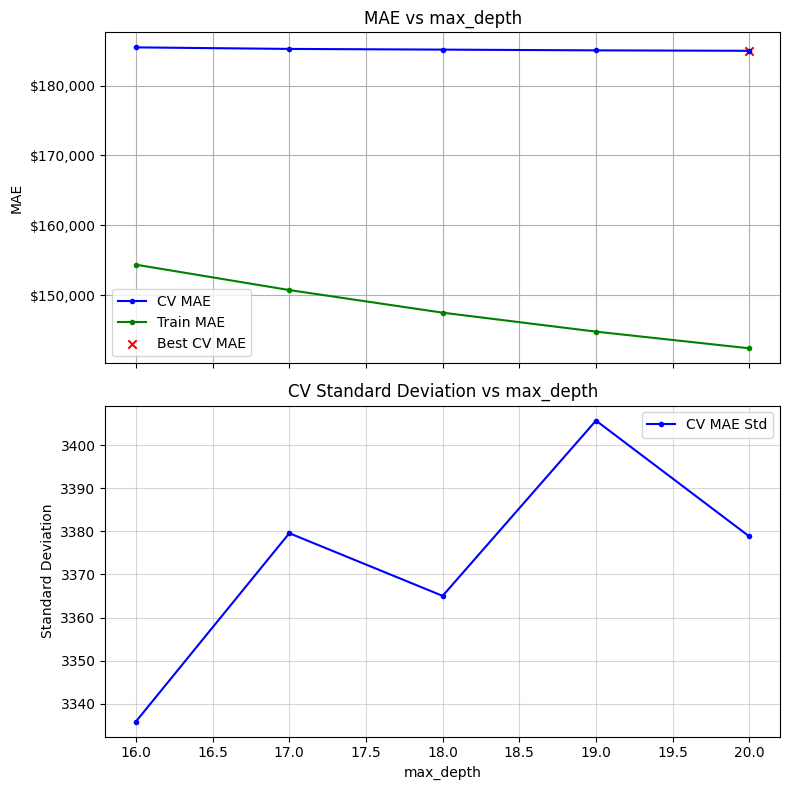

Execution Time: 00:32:37


{'n_estimators': 700,
 'random_state': 42,
 'max_depth': 20,
 'MAE_found': np.float64(184968.86982271043),
 'STD_found': np.float64(3378.8063519155276),
 'min_samples_leaf': 4,
 'max_features': 5,
 'min_samples_split': 10}

In [44]:
# Fine-tuning max_depth with a more focused range based on previous results
Params_RF = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=Params_RF,
    param="max_depth",
    parameter_list=[16 , 17, 18, 19, 20],
    X_train=X_train_rf_selected,
    y_train=y_train,
    show_std=True,
    n_repeats=3,
    n_jobs=-1
)
Params_RF

Sweeping min_samples_leaf: 100%|██████████| 5/5 [34:08<00:00, 409.63s/it]


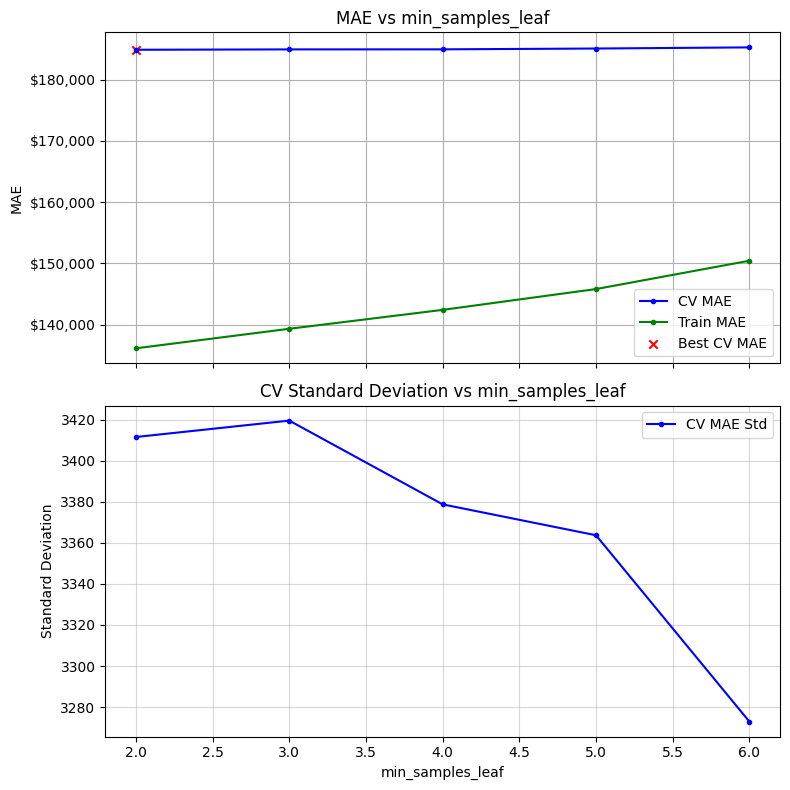

Execution Time: 00:34:08


In [45]:
# Fine-tuning min_samples_leaf with a more focused range based on previous results
min_samples_leaf_values = [2, 3, 4, 5, 6]

Params_RF = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=Params_RF,
    param="min_samples_leaf",
    parameter_list=min_samples_leaf_values,
    X_train=X_train_rf_selected,
    y_train=y_train,
    show_std=True,
    n_repeats=3,
    n_jobs=-1
)

Sweeping max_features: 100%|██████████| 5/5 [39:45<00:00, 477.01s/it]


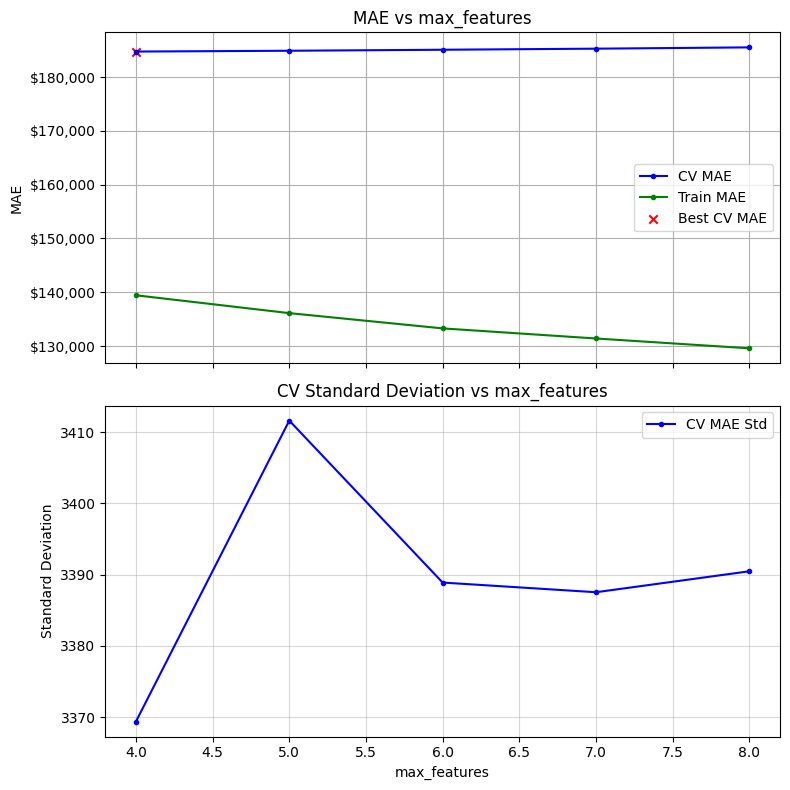

Execution Time: 00:39:45


{'n_estimators': 700,
 'random_state': 42,
 'max_depth': 20,
 'MAE_found': np.float64(184748.48626371147),
 'STD_found': np.float64(3369.377072650395),
 'min_samples_leaf': 2,
 'max_features': 4,
 'min_samples_split': 10}

In [46]:
# Fine-tuning max_features with a more focused range based on previous results
max_features_values = [4, 5, 6, 7, 8]

Params_RF = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=Params_RF,
    param="max_features",
    parameter_list=max_features_values,
    X_train=X_train_rf_selected,
    y_train=y_train,
    show_std=True,
    n_repeats=3,
    n_jobs=-1
)

Params_RF

Sweeping min_samples_split: 100%|██████████| 5/5 [28:22<00:00, 340.56s/it]


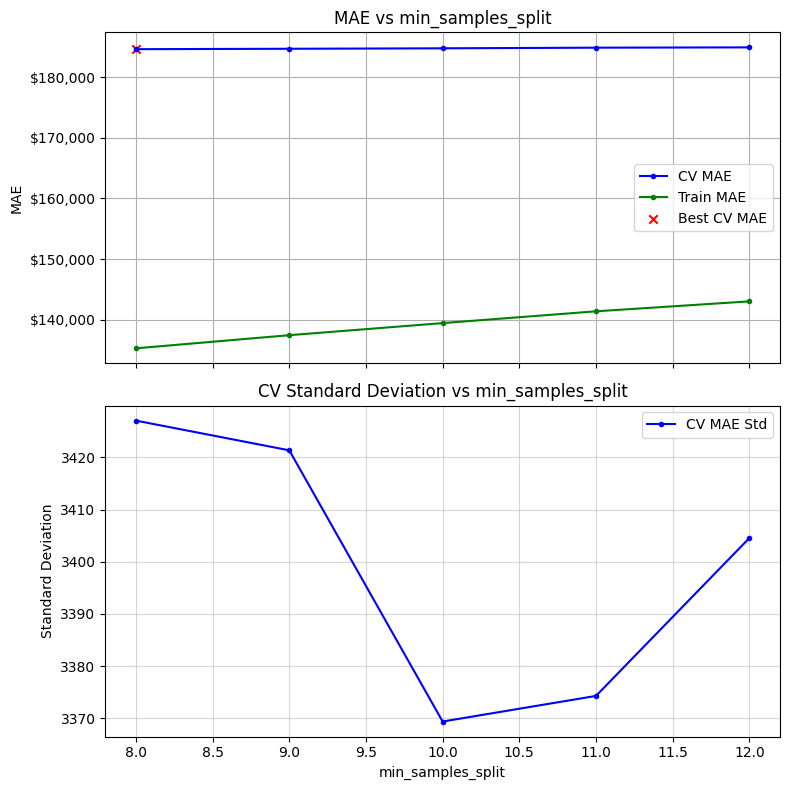

Execution Time: 00:28:22


{'n_estimators': 700,
 'random_state': 42,
 'max_depth': 20,
 'MAE_found': np.float64(184604.79932285583),
 'STD_found': np.float64(3427.0502605171173),
 'min_samples_leaf': 2,
 'max_features': 4,
 'min_samples_split': 8}

In [47]:
# Fine-tuning min_samples_split with a more focused range based on previous results
min_samples_split_values = [8, 9, 10, 11, 12]

Params_RF = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=Params_RF,
    param="min_samples_split",
    parameter_list=min_samples_split_values,
    X_train=X_train_rf_selected,
    y_train=y_train,
    show_std=True,
    n_repeats=3,
    n_jobs=-1
)

Params_RF

Sweeping n_estimators: 100%|██████████| 4/4 [24:44<00:00, 371.19s/it]


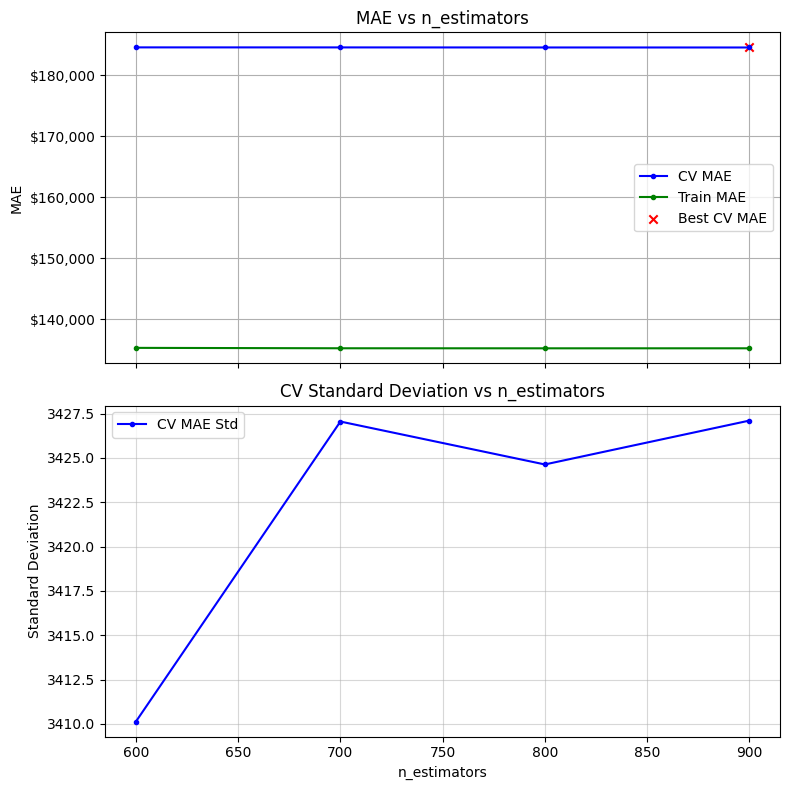

Execution Time: 00:24:44


{'n_estimators': 900,
 'random_state': 42,
 'max_depth': 20,
 'MAE_found': np.float64(184591.51214898677),
 'STD_found': np.float64(3427.1034333586686),
 'min_samples_leaf': 2,
 'max_features': 4,
 'min_samples_split': 8}

In [48]:
# Fine-tuning n_estimators with a more focused range based on previous results
n_estimators_values = [600, 700, 800, 900]

Params_RF = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=Params_RF,
    param="n_estimators",
    parameter_list=n_estimators_values,
    X_train=X_train_rf_selected,
    y_train=y_train,
    show_std=True,
    n_repeats=3,
    n_jobs=-1
)

Params_RF

In [49]:
rf_param_distributions = {
    "n_estimators": [700, 800, 900, 1000],
    "max_depth": [16, 17, 18, 19, 20],
    "min_samples_leaf": [2, 3, 4, 5],
    "max_features": [3, 4, 5, 6, 7],
    "min_samples_split": [6, 7, 8, 9, 10]
}

cv_random = KFold(n_splits=5,shuffle=True,random_state=random_seed)

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=random_seed, n_jobs= 1),
    param_distributions=rf_param_distributions,
    n_iter=100,
    scoring="neg_mean_absolute_error",
    cv=cv_random,
    random_state=random_seed,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

rf_random_search.fit(X_train_rf_selected, y_train)

print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest CV MAE:")
print(-rf_random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters:
{'n_estimators': 1000, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 4, 'max_depth': 20}

Best CV MAE:
184889.5987080311


In [50]:
# Random Forest Model Comparison (Focused Sweeps vs RandomizedSearchCV)

# Best parameters from the sequential sweeps
sweep_params = Params_RF.copy()

# Remove stored evaluation results because they are not model parameters
sweep_params.pop("MAE_found", None)
sweep_params.pop("STD_found", None)

# Best parameters from RandomizedSearchCV
random_search_params = rf_random_search.best_params_.copy()

# Control parallel processing inside each Random Forest
sweep_params["random_state"] = random_seed
sweep_params["n_jobs"] = 1

random_search_params["random_state"] = random_seed
random_search_params["n_jobs"] = 1

rf_candidates = {
    "Focused Sweeps": RandomForestRegressor(**sweep_params),
    "Randomized Search": RandomForestRegressor(**random_search_params)}

final_cv = RepeatedKFold(n_splits=5,n_repeats=5,random_state=random_seed)

comparison_results = []
candidate_scores = {}

for model_name, model in rf_candidates.items():

    cv_scores = -cross_val_score(
        estimator=model,
        X=X_train_rf_selected,
        y=y_train,
        scoring="neg_mean_absolute_error",
        cv=final_cv,
        n_jobs=-1
    )

    candidate_scores[model_name] = cv_scores

    model.fit(X_train_rf_selected, y_train)
    train_predictions = model.predict(X_train_rf_selected)
    train_mae = mean_absolute_error(y_train, train_predictions)

    comparison_results.append({
        "Model": model_name,
        "Train MAE": train_mae,
        "Mean CV MAE": cv_scores.mean(),
        "CV MAE Standard Deviation": cv_scores.std(),
        "Train-CV Gap": cv_scores.mean() - train_mae})

rf_tuning_comparison = pd.DataFrame(comparison_results).sort_values("Mean CV MAE").reset_index(drop=True)
rf_tuning_comparison

,Model,Train MAE,Mean CV MAE,CV MAE Standard Deviation,Train-CV Gap
0,Focused Sweeps,135278.128977,184632.860974,2883.609310,49354.731997
1,Randomized Search,135296.997099,184641.308570,2880.728267,49344.311471


**Final Random Forest Tuning Result**

We compared the best model from the focused parameter sweeps with the best model from RandomizedSearchCV using repeated 5-fold cross-validation with 5 repeats.

The two models produced nearly identical results. The focused-sweep model had a slightly lower mean cross-validation MAE of 184,632.86, compared with 184,641.31 for the Randomized Search model. Therefore, we selected the focused-sweep model as the final tuned Random Forest model.

### **HistGradientBoosting Regressor Tunning**

In [55]:
Default_Parameters_GB = {
    'loss'                      :'squared_error',   # The loss function to use in the boosting process. Note that the “squared error”, “gamma” and “poisson” losses actually implement “half least squares loss”, “half gamma deviance” and “half poisson deviance” to simplify the computation of the gradient. Furthermore, “gamma” and “poisson” losses internally use a log-link, “gamma” requires y > 0 and “poisson” requires y >= 0. “quantile” uses the pinball loss.
    #'n_estimators'             : 100,              # The number of boosting stages to be run. More estimators can improve performance but increase training time. - Not used Hist Gradient Boosting
    'quantile'                  : None,             # If loss is “quantile”, this parameter specifies which quantile to be estimated and must be between 0 and 1.
    'learning_rate'             : 0.1,              # The learning rate, also known as shrinkage. This is used as a multiplicative factor for the leaves values. Use 1 for no shrinkage.
    'max_iter'                  : 100,              # Use for Hist Gradient boosting instead of n_estimators - The maximum number of iterations of the boosting process, i.e. the maximum number of trees.
    'max_leaf_nodes'            : 31,               # The maximum number of leaves for each tree. Must be strictly greater than 1. If None, there is no maximum limit.
    'max_depth'                 : None,             # The maximum depth of each tree. The depth of a tree is the number of edges to go from the root to the deepest leaf. Depth isn’t constrained by default. Used default = 3 in previous homework
    'max_features'              : 1.0,              # Number of features to consider when looking for best split. Can help reduce overfitting. # Proportion of randomly chosen features in each and every node split. This is a form of regularization, smaller values make the trees weaker learners and might prevent overfitting. If interaction constraints from interaction_cst are present, only allowed features are taken into account for the subsampling.
    #'min_samples_split'        : 2,                # Defines the minimum number of samples required to split an internal node. - Not used Hist Gradient Boosting
    'min_samples_leaf'          :20,                 # Use for hist gradient boosting instead of min_samples_split - The minimum number of samples per leaf. For small datasets with less than a few hundred samples, it is recommended to lower this value since only very shallow trees would be built. 
    'l2_regularization'         :0,                 # The L2 regularization parameter penalizing leaves with small hessians. Use 0 for no regularization (default).
    #'subsample'                : 1.0,              # Fraction of the training data used to train each tree; values less than 1.0 introduce randomness and can reduce overfitting. Not used in Hist Gradient Boosting. Use max_features instead
    'max_bins'                  :255,               # The maximum number of bins to use for non-missing values. Before training, each feature of the input array X is binned into integer-valued bins, which allows for a much faster training stage. Features with a small number of unique values may use less than max_bins bins. In addition to the max_bins bins, one more bin is always reserved for missing values. Must be no larger than 255.
    'categorical_features'      :'from_dtype',      # array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default=’from_dtype’
                                                    # Indicates the categorical features.
                                                    # None : no feature will be considered categorical.
                                                    # boolean array-like : boolean mask indicating categorical features.
                                                    # integer array-like : integer indices indicating categorical features.
                                                    # str array-like: names of categorical features (assuming the training data has feature names).
                                                    # "from_dtype": dataframe columns with dtype “Categorical” and “Enum” are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): narwhals.from_native must work. This is the case, for instance, for pandas and polars DataFrames.
                                                    # For each categorical feature, there must be at most max_bins unique categories. Negative values for categorical features encoded as numeric dtypes are treated as missing values. All categorical values are converted to floating point numbers. This means that categorical values of 1.0 and 1 are treated as the same category.

    'random_state'            : random_seed,        # Controls randomness of boosting. Useful for reproducibility.
    'verbose'                  : 0,                 # Print some information about the fitting process. 2 gives info for each interation - will give info for each sweep in n-folds. May be useful for performance tuning
    'MAE_found'               : float('inf'),       # NOT a model parameter, but will record the MAE found for the current parameter choices
    'STD_found'               : float('inf')        # NOT a model parameter, but will record the Std. Dev found for the associated best MAE - this was added as part of Milestone 2 testing

}

In [56]:
Params_GB = Default_Parameters_GB.copy()

Sweeping max_iter: 100%|██████████| 5/5 [00:07<00:00,  1.55s/it]


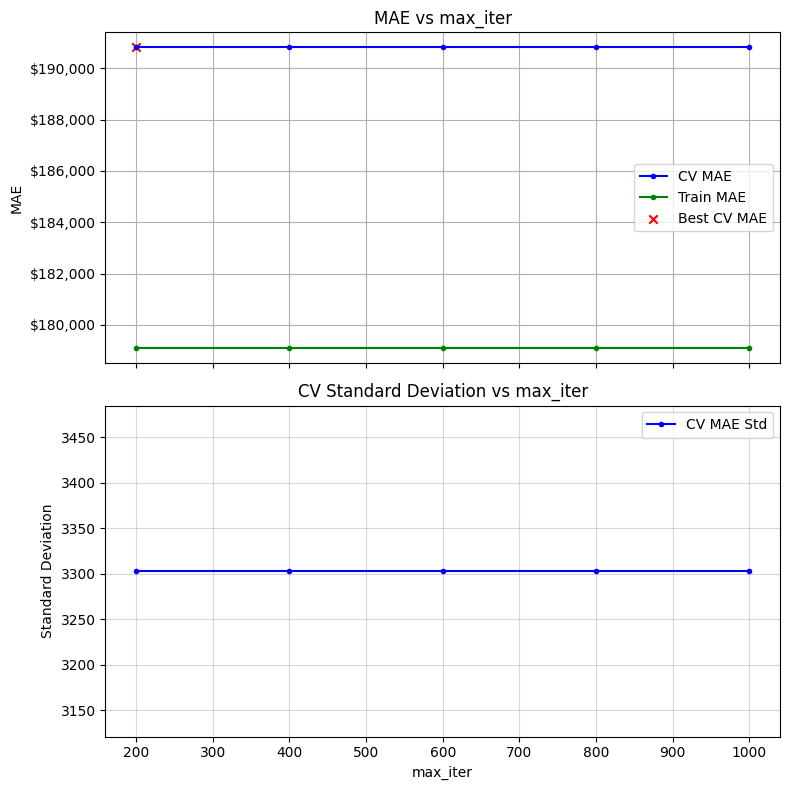

Execution Time: 00:00:08


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': 200,
 'max_leaf_nodes': 31,
 'max_depth': None,
 'max_features': 1.0,
 'min_samples_leaf': 20,
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(190818.11014275206),
 'STD_found': np.float64(3303.0180967800197)}

In [57]:
# Try range of iterations in steps of 200 to start
Params_GB = sweep_parameter(
    model = HistGradientBoostingRegressor(random_state=42),
    Parameters = Params_GB,
    param='max_iter',
    parameter_list=range(200, 1200, 200),
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)
Params_GB

Sweeping max_iter: 100%|██████████| 40/40 [01:39<00:00,  2.48s/it]


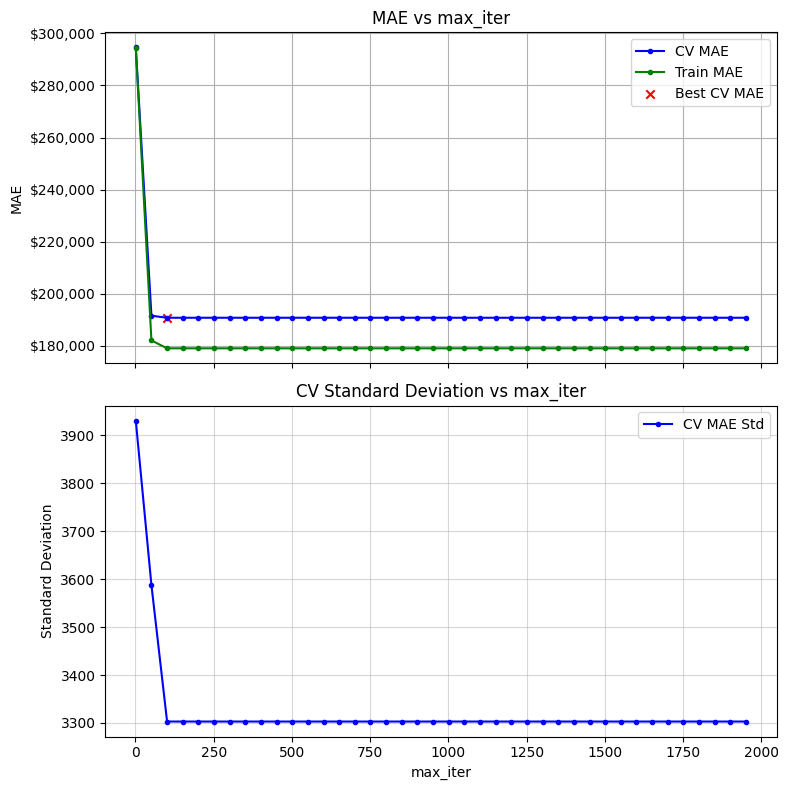

Execution Time: 00:01:39


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': 101,
 'max_leaf_nodes': 31,
 'max_depth': None,
 'max_features': 1.0,
 'min_samples_leaf': 20,
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(190818.11014275206),
 'STD_found': np.float64(3303.0180967800197)}

In [58]:
# Try range of iterations in steps of increase range and steps to narrow since run was fast
Params_GB = sweep_parameter(
    model = HistGradientBoostingRegressor(random_state=42),
    Parameters = Params_GB,
    param='max_iter',
    parameter_list=range(1, 2001, 50),
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)
Params_GB

Sweeping max_iter: 100%|██████████| 150/150 [06:20<00:00,  2.54s/it]


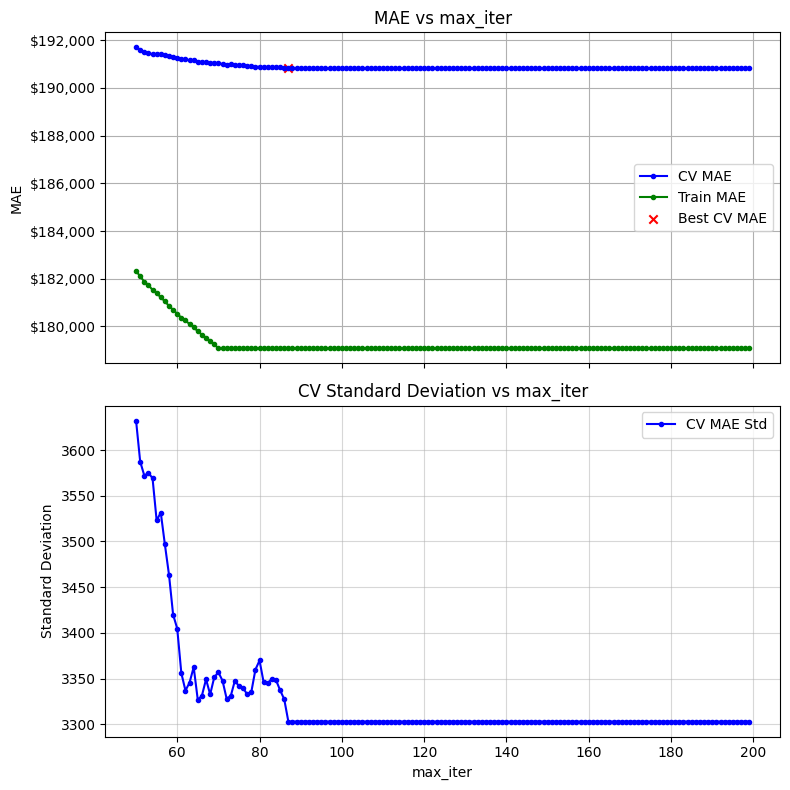

Execution Time: 00:06:21


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': 87,
 'max_leaf_nodes': 31,
 'max_depth': None,
 'max_features': 1.0,
 'min_samples_leaf': 20,
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(190818.11014275206),
 'STD_found': np.float64(3303.0180967800197)}

In [59]:
# Increase iterations and reduce range - should be relatively optimized for iterations - CV MAE is marginally lower
Params_GB = sweep_parameter(
    model = HistGradientBoostingRegressor(random_state=42),
    Parameters = Params_GB,
    param='max_iter',
    parameter_list=range(50, 200, 1),
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)
Params_GB

Sweeping max_depth: 100%|██████████| 15/15 [00:30<00:00,  2.01s/it]


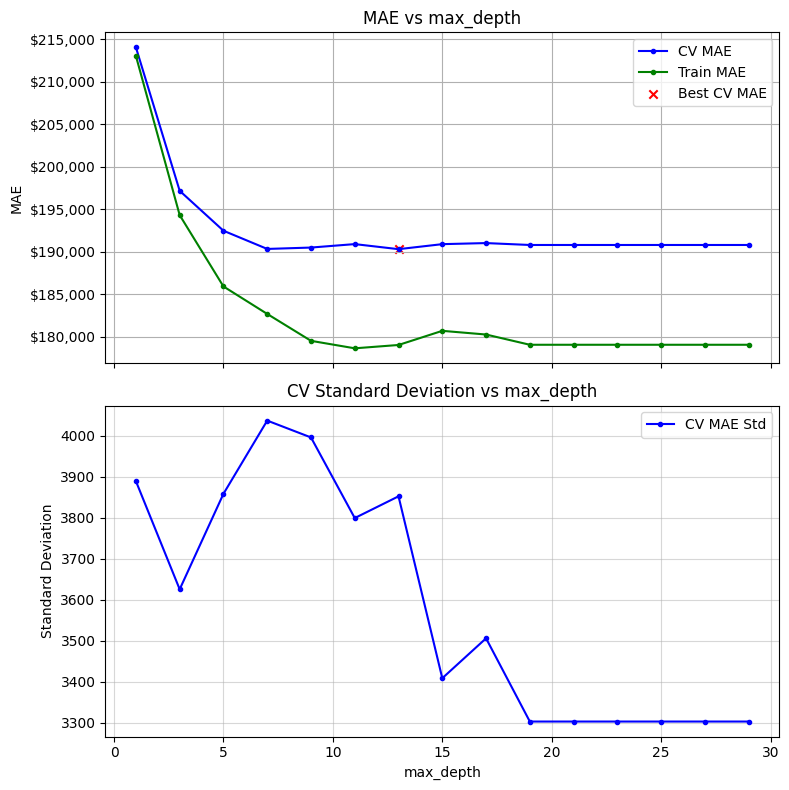

Execution Time: 00:00:30


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': 87,
 'max_leaf_nodes': 31,
 'max_depth': 13,
 'max_features': 1.0,
 'min_samples_leaf': 20,
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(190325.85598597492),
 'STD_found': np.float64(3852.3935860512247)}

In [60]:
# Tune max depth 
Params_GB = sweep_parameter(
    model = HistGradientBoostingRegressor(random_state=42),
    Parameters = Params_GB, 
    param='max_depth', 
    parameter_list=range(1, 30, 2),
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)
Params_GB

Sweeping max_depth: 100%|██████████| 20/20 [00:37<00:00,  1.89s/it]


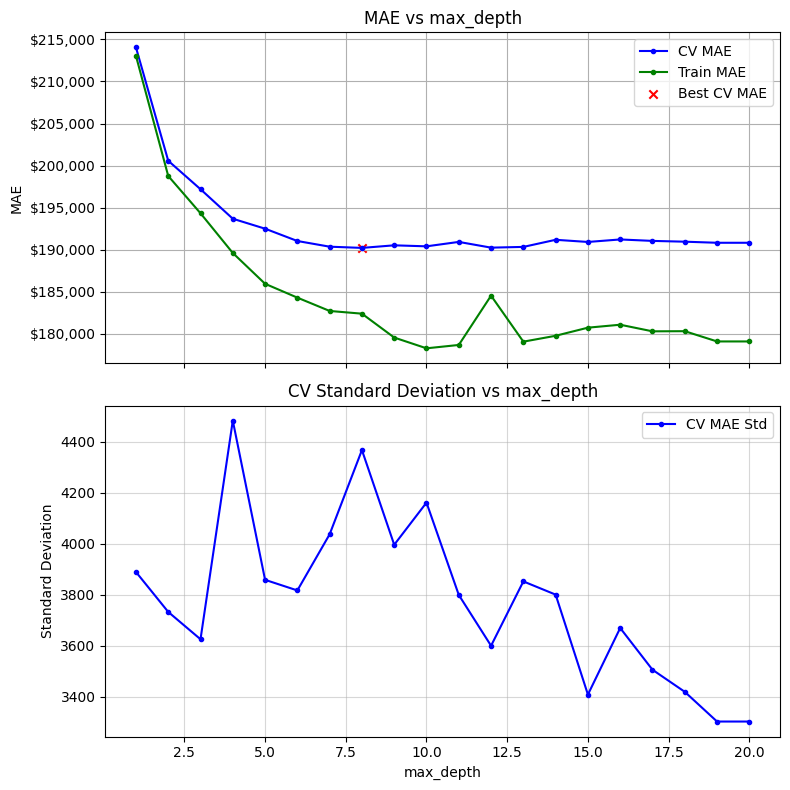

Execution Time: 00:00:38


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': 87,
 'max_leaf_nodes': 31,
 'max_depth': 8,
 'max_features': 1.0,
 'min_samples_leaf': 20,
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(190208.48145538275),
 'STD_found': np.float64(4367.226452617052)}

In [61]:
# Tune max depth with a more focused range based on previous results
Params_GB = sweep_parameter(
    model = HistGradientBoostingRegressor(random_state=42),
    Parameters = Params_GB, 
    param='max_depth', 
    parameter_list=range(1, 21, 1),
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)
Params_GB

Sweeping max_features: 100%|██████████| 10/10 [00:17<00:00,  1.75s/it]


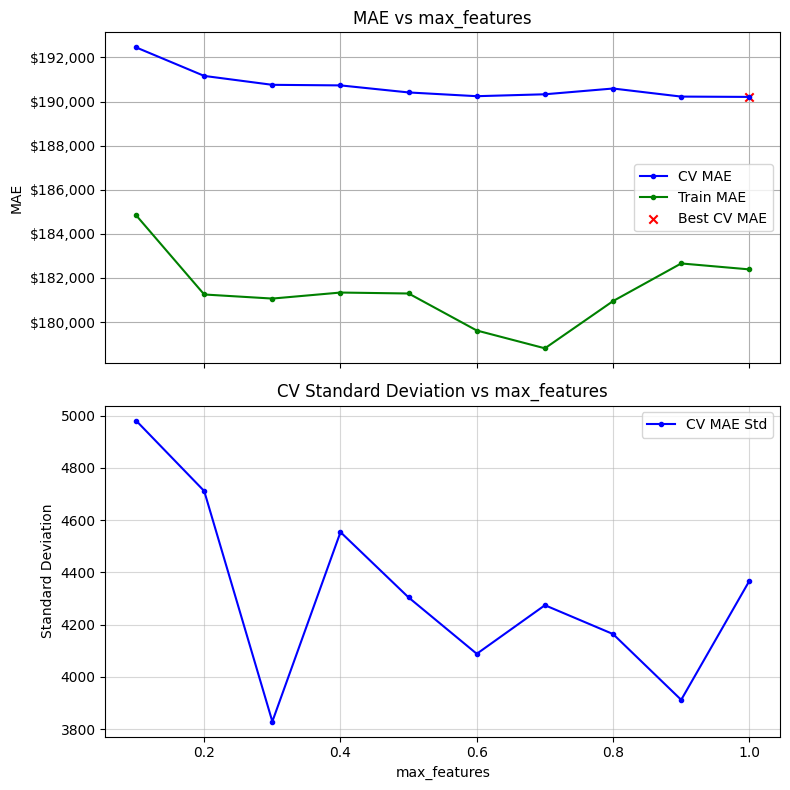

Execution Time: 00:00:17


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': 87,
 'max_leaf_nodes': 31,
 'max_depth': 8,
 'max_features': np.float64(1.0),
 'min_samples_leaf': 20,
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(190208.48145538275),
 'STD_found': np.float64(4367.226452617052)}

In [62]:
# Tune max features - use a range of proportions from 0.1 to 1.0 in increments of 0.1
Params_GB = sweep_parameter(
    model = HistGradientBoostingRegressor(random_state=42),
    Parameters = Params_GB, 
    param='max_features', 
    parameter_list=np.arange(0.1, 1.01, 0.1),
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)
Params_GB

Sweeping min_samples_leaf: 100%|██████████| 40/40 [01:45<00:00,  2.65s/it]


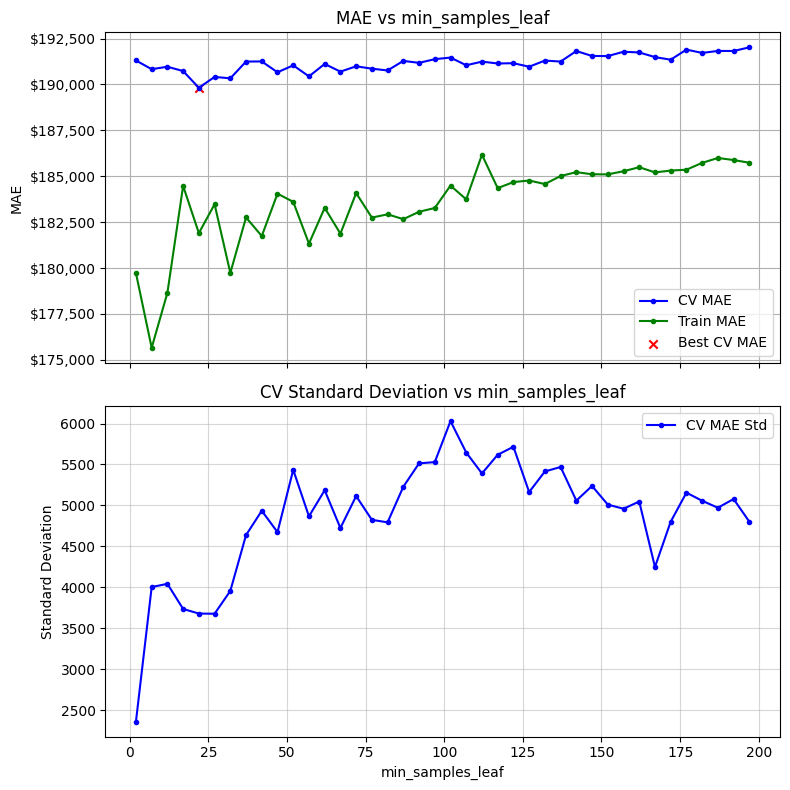

Execution Time: 00:01:46


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': 87,
 'max_leaf_nodes': 31,
 'max_depth': 8,
 'max_features': np.float64(1.0),
 'min_samples_leaf': np.int64(22),
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(189817.0444652079),
 'STD_found': np.float64(3678.5772073689814)}

In [63]:
# Tune min_samples_leaf 
Params_GB = sweep_parameter(
    model = HistGradientBoostingRegressor(random_state=42),
    Parameters = Params_GB, 
    param='min_samples_leaf', 
    parameter_list= np.arange(2, 200, 5),
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)
Params_GB

Sweeping min_samples_leaf: 100%|██████████| 98/98 [04:05<00:00,  2.50s/it]


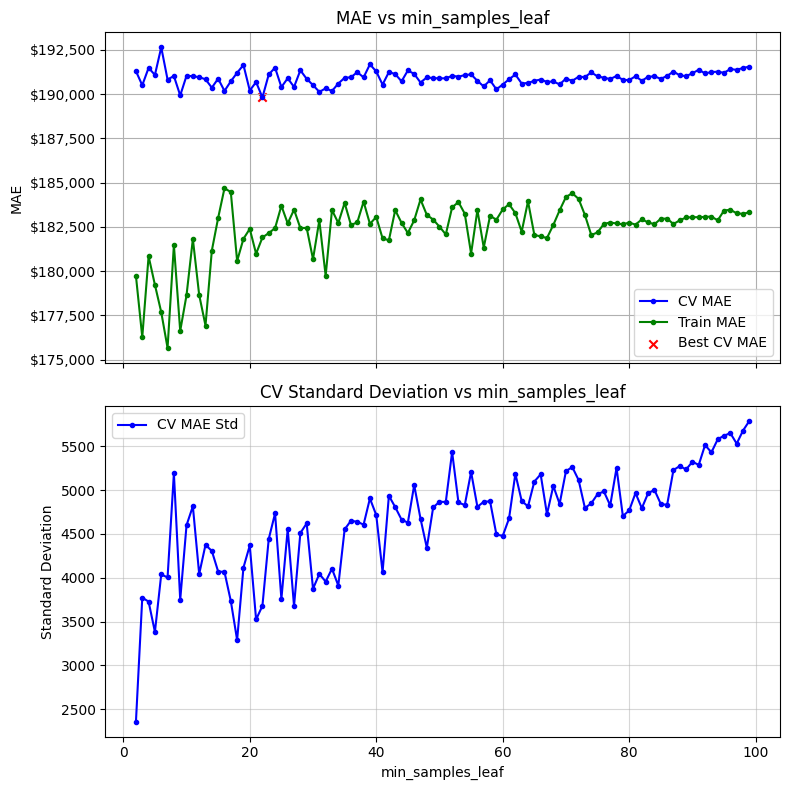

Execution Time: 00:04:05


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': 87,
 'max_leaf_nodes': 31,
 'max_depth': 8,
 'max_features': np.float64(1.0),
 'min_samples_leaf': np.int64(22),
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(189817.0444652079),
 'STD_found': np.float64(3678.5772073689814)}

In [64]:
# Tune min_samples_leaf with a more focused range based on previous results
Params_GB = sweep_parameter(
    model = HistGradientBoostingRegressor(random_state=42),
    Parameters = Params_GB, 
    param='min_samples_leaf', 
    parameter_list= np.arange(2, 100, 1),
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)
Params_GB

Sweeping max_leaf_nodes: 100%|██████████| 49/49 [02:22<00:00,  2.92s/it]


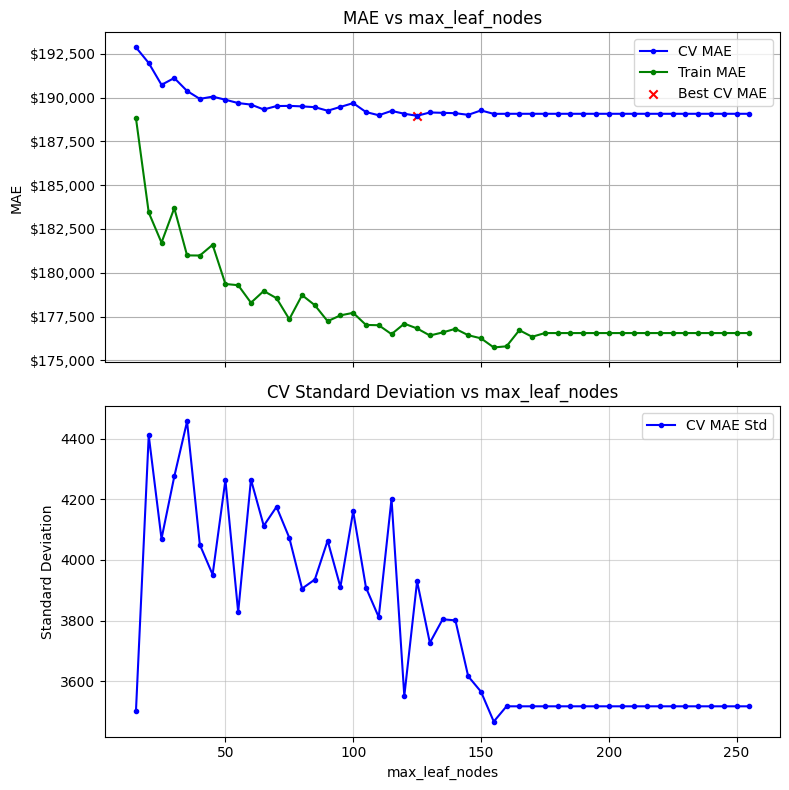

Execution Time: 00:02:23


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': 87,
 'max_leaf_nodes': np.int64(125),
 'max_depth': 8,
 'max_features': np.float64(1.0),
 'min_samples_leaf': np.int64(22),
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(188956.2165296428),
 'STD_found': np.float64(3929.534940840223)}

In [65]:
# Tune max leaf nodes 
Params_GB = sweep_parameter(
    model = HistGradientBoostingRegressor(random_state=42),
    Parameters = Params_GB, 
    param='max_leaf_nodes', 
    parameter_list= np.arange(15, 256, 5),
    show_std=True,
    n_repeats=1,
    n_jobs=-1
)
Params_GB

Sweeping max_iter: 100%|██████████| 21/21 [01:52<00:00,  5.37s/it]


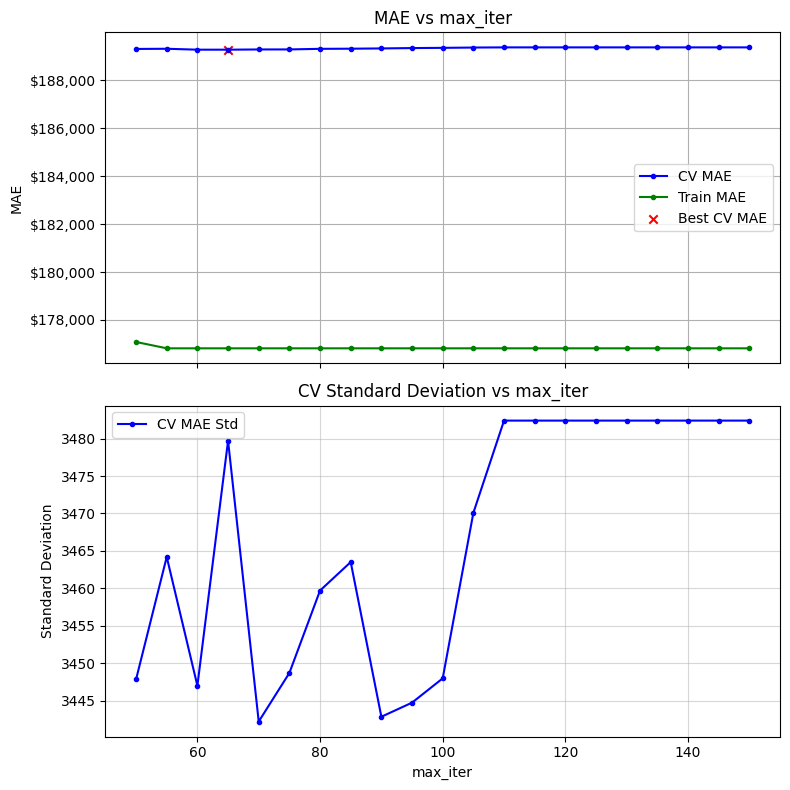

Execution Time: 00:01:53


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': np.int64(65),
 'max_leaf_nodes': np.int64(125),
 'max_depth': 8,
 'max_features': np.float64(1.0),
 'min_samples_leaf': np.int64(22),
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(189275.42554798964),
 'STD_found': np.float64(3479.727993807658)}

In [67]:
# Round 2: refine max_iter with 3 and 5 repeats
Params_GB = sweep_parameter(
    model=HistGradientBoostingRegressor(random_state=42),
    Parameters=Params_GB,
    param='max_iter',
    parameter_list=np.arange(50, 151, 5),
    show_std=True,
    n_repeats=3,
    n_jobs=-1
)

Params_GB

Sweeping max_depth: 100%|██████████| 16/16 [02:15<00:00,  8.45s/it]


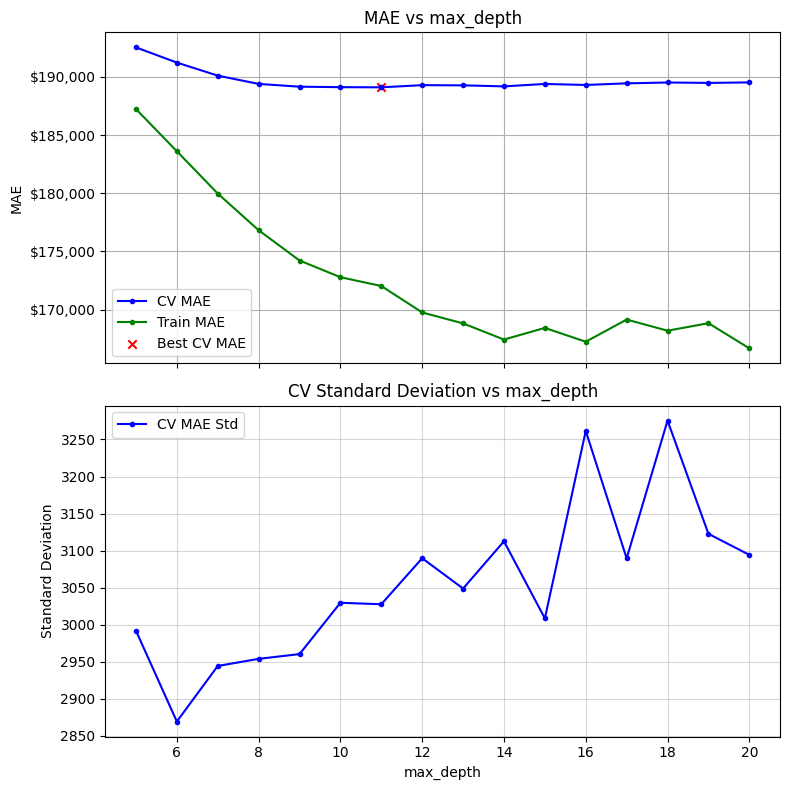

Execution Time: 00:02:15


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': np.int64(65),
 'max_leaf_nodes': np.int64(125),
 'max_depth': np.int64(11),
 'max_features': np.float64(1.0),
 'min_samples_leaf': np.int64(22),
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(189103.38634466325),
 'STD_found': np.float64(3027.568777110004)}

In [68]:
# Round 2: refine max_depth with 5 repeats
Params_GB = sweep_parameter(
    model=HistGradientBoostingRegressor(random_state=42),
    Parameters=Params_GB,
    param='max_depth',
    parameter_list=np.arange(5, 21, 1),
    show_std=True,
    n_repeats=5,
    n_jobs=-1
)

Params_GB

Sweeping max_features: 100%|██████████| 26/26 [04:04<00:00,  9.42s/it]


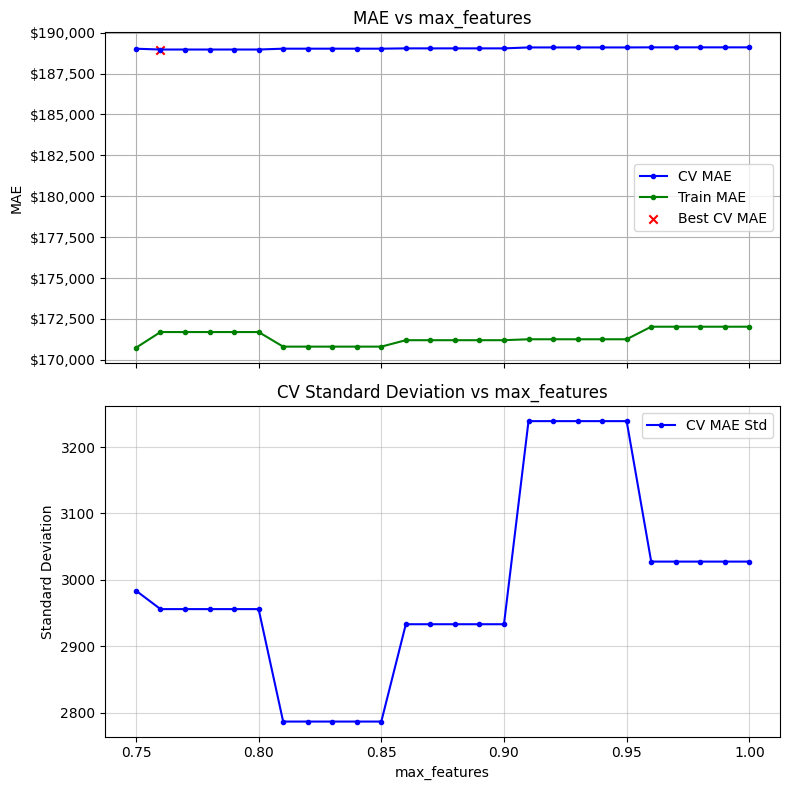

Execution Time: 00:04:05


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': np.int64(65),
 'max_leaf_nodes': np.int64(125),
 'max_depth': np.int64(11),
 'max_features': np.float64(0.76),
 'min_samples_leaf': np.int64(22),
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(188970.6700487936),
 'STD_found': np.float64(2956.0596749835495)}

In [70]:
# Round 2: refine max_features with 5 repeats
Params_GB = sweep_parameter(
    model=HistGradientBoostingRegressor(random_state=42),
    Parameters=Params_GB,
    param='max_features',
    parameter_list=np.round(np.arange(0.75, 1.01, 0.01), 2),
    show_std=True,
    n_repeats=5,
    n_jobs=-1
)

Params_GB

Sweeping min_samples_leaf: 100%|██████████| 51/51 [08:09<00:00,  9.60s/it]


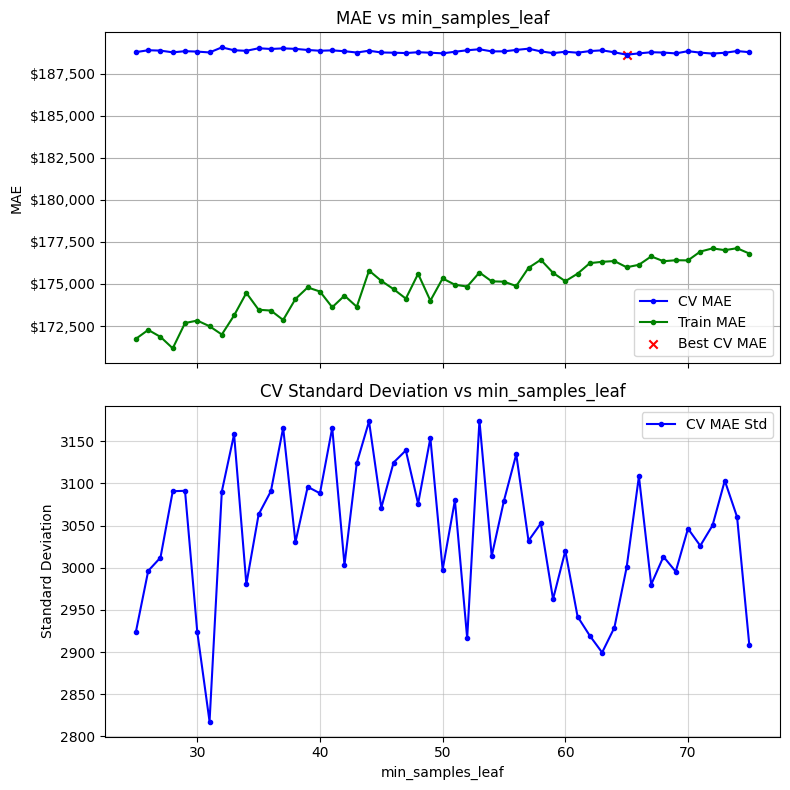

Execution Time: 00:08:10


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': np.int64(65),
 'max_leaf_nodes': np.int64(125),
 'max_depth': np.int64(11),
 'max_features': np.float64(0.76),
 'min_samples_leaf': np.int64(65),
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(188628.90253638182),
 'STD_found': np.float64(3000.5742569791087)}

In [73]:
# Round 2: refine min_samples_leaf with 5 repeats
Params_GB = sweep_parameter(
    model=HistGradientBoostingRegressor(random_state=42),
    Parameters=Params_GB,
    param='min_samples_leaf',
    parameter_list=np.arange(25, 76, 1),
    show_std=True,
    n_repeats=5,
    n_jobs=-1
)

Params_GB

Sweeping max_leaf_nodes: 100%|██████████| 126/126 [19:26<00:00,  9.26s/it]


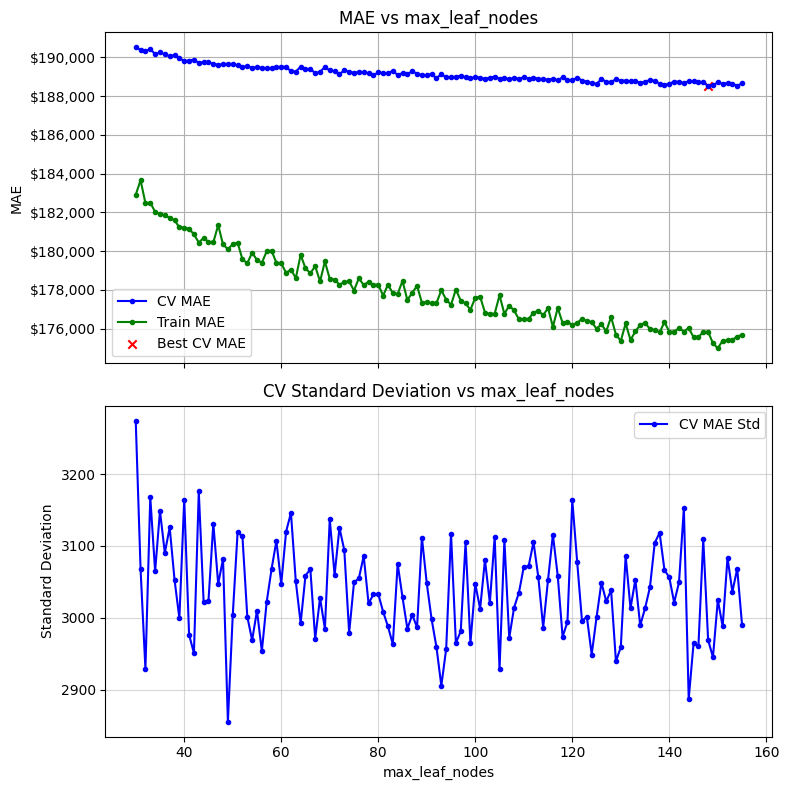

Execution Time: 00:19:26


{'loss': 'squared_error',
 'quantile': None,
 'learning_rate': 0.1,
 'max_iter': np.int64(65),
 'max_leaf_nodes': np.int64(148),
 'max_depth': np.int64(11),
 'max_features': np.float64(0.76),
 'min_samples_leaf': np.int64(65),
 'l2_regularization': 0,
 'max_bins': 255,
 'categorical_features': 'from_dtype',
 'random_state': 42,
 'verbose': 0,
 'MAE_found': np.float64(188521.7964641424),
 'STD_found': np.float64(2969.2198512196496)}

In [74]:
# Round 2: refine max_leaf_nodes with 5 repeats
Params_GB = sweep_parameter(
    model=HistGradientBoostingRegressor(random_state=42),
    Parameters=Params_GB,
    param='max_leaf_nodes',
    parameter_list=np.arange(30, 156, 1),
    show_std=True,
    n_repeats=5,
    n_jobs=-1
)

Params_GB

#### HistGradientBoosting: Baseline vs Individual Hyperparameter Changes    


In [75]:
# Try using default values to get baseline then compare each in turn
hgb_default = baseline_results.iloc[1]
print(hgb_default)

hgb_results = []

Experiment                               Baseline
Model                        HistGradientBoosting
Mean CV MAE                         191285.873656
CV MAE Standard Deviation             3186.693565
Name: 1, dtype: object


In [76]:
hgb_iter = sweep_parameter(
    model=HistGradientBoostingRegressor(random_state=42),
    Parameters=Default_Parameters_GB,
    param='max_iter',
    parameter_list=np.arange(65, 66, 1),
    show_mae=False,
    show_std=False,
    verbose=0
)

print(hgb_iter)
hgb_results.append(hgb_iter)

Sweeping max_iter: 100%|██████████| 1/1 [00:07<00:00,  7.84s/it]

{'loss': 'squared_error', 'quantile': None, 'learning_rate': 0.1, 'max_iter': np.int64(65), 'max_leaf_nodes': 31, 'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 20, 'l2_regularization': 0, 'max_bins': 255, 'categorical_features': 'from_dtype', 'random_state': 42, 'verbose': 0, 'MAE_found': np.float64(191737.25856870596), 'STD_found': np.float64(2729.320616089186)}


In [77]:
hgb_results

[{'loss': 'squared_error',
  'quantile': None,
  'learning_rate': 0.1,
  'max_iter': np.int64(65),
  'max_leaf_nodes': 31,
  'max_depth': None,
  'max_features': 1.0,
  'min_samples_leaf': 20,
  'l2_regularization': 0,
  'max_bins': 255,
  'categorical_features': 'from_dtype',
  'random_state': 42,
  'verbose': 0,
  'MAE_found': np.float64(191737.25856870596),
  'STD_found': np.float64(2729.320616089186)}]

In [78]:
hgb_depth = sweep_parameter(
    model=HistGradientBoostingRegressor(random_state=42),
    Parameters=Default_Parameters_GB,
    param='max_depth',
    parameter_list=np.arange(11, 12, 1),
    show_mae=False,
    show_std=False,
    verbose=0
)

print(hgb_depth)
hgb_results.append(hgb_depth)

Sweeping max_depth: 100%|██████████| 1/1 [00:02<00:00,  2.46s/it]

{'loss': 'squared_error', 'quantile': None, 'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 31, 'max_depth': np.int64(11), 'max_features': 1.0, 'min_samples_leaf': 20, 'l2_regularization': 0, 'max_bins': 255, 'categorical_features': 'from_dtype', 'random_state': 42, 'verbose': 0, 'MAE_found': np.float64(191510.3575471533), 'STD_found': np.float64(3007.347479729577)}


Sweeping max_features: 100%|██████████| 1/1 [00:02<00:00,  2.72s/it]


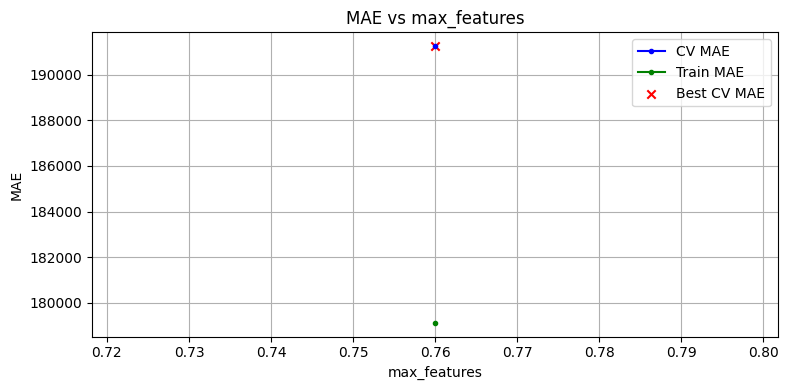

Execution Time: 00:00:02
{'loss': 'squared_error', 'quantile': None, 'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 31, 'max_depth': None, 'max_features': np.float64(0.76), 'min_samples_leaf': 20, 'l2_regularization': 0, 'max_bins': 255, 'categorical_features': 'from_dtype', 'random_state': 42, 'verbose': 0, 'MAE_found': np.float64(191248.25032227737), 'STD_found': np.float64(2994.1963369797495)}


In [80]:
hgb_features = sweep_parameter(
    model=HistGradientBoostingRegressor(random_state=42),
    Parameters=Default_Parameters_GB,
    param='max_features',
    parameter_list=np.arange(0.76, 0.77, 1),
    show_mae=False,
    show_std=False
)

print(hgb_features)
hgb_results.append(hgb_features)

In [81]:
hgb_leaf = sweep_parameter(
    model=HistGradientBoostingRegressor(random_state=42),
    Parameters=Default_Parameters_GB,
    param='min_samples_leaf',
    parameter_list=np.arange(65, 66, 1),
    show_mae=False,
    show_std=False,
    verbose=0
)

print(hgb_leaf)
hgb_results.append(hgb_leaf)

Sweeping min_samples_leaf: 100%|██████████| 1/1 [00:02<00:00,  2.80s/it]

{'loss': 'squared_error', 'quantile': None, 'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 31, 'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': np.int64(65), 'l2_regularization': 0, 'max_bins': 255, 'categorical_features': 'from_dtype', 'random_state': 42, 'verbose': 0, 'MAE_found': np.float64(190368.43945689255), 'STD_found': np.float64(3248.598462935949)}


In [82]:
hgb_leaf_nodes = sweep_parameter(
    model=HistGradientBoostingRegressor(random_state=42),
    Parameters=Default_Parameters_GB,
    param='max_leaf_nodes',
    parameter_list=np.arange(148, 149, 1),
    show_mae=False,
    show_std=False,
    verbose=0
)

print(hgb_leaf_nodes)
hgb_results.append(hgb_leaf_nodes)

Sweeping max_leaf_nodes: 100%|██████████| 1/1 [00:07<00:00,  7.74s/it]

{'loss': 'squared_error', 'quantile': None, 'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': np.int64(148), 'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 20, 'l2_regularization': 0, 'max_bins': 255, 'categorical_features': 'from_dtype', 'random_state': 42, 'verbose': 0, 'MAE_found': np.float64(189810.1875433012), 'STD_found': np.float64(3077.672741067188)}


In [83]:
# Summarize baseline and individual hyperparameter changes

hgb_comparison = pd.DataFrame({"Change": ["Baseline","max_iter","max_depth","max_features","min_samples_leaf","max_leaf_nodes"],
                               "Value": ["Default",65,11,0.76,65,148],
                               "CV_MAE": [hgb_default["Mean CV MAE"],hgb_iter["MAE_found"],hgb_depth["MAE_found"],hgb_features["MAE_found"],hgb_leaf["MAE_found"],hgb_leaf_nodes["MAE_found"]],
                               "CV_STD": [hgb_default["CV MAE Standard Deviation"],hgb_iter["STD_found"],hgb_depth["STD_found"],hgb_features["STD_found"],hgb_leaf["STD_found"],hgb_leaf_nodes["STD_found"]]})

hgb_comparison["MAE_Improvement_vs_Baseline"] = (hgb_comparison.loc[0, "CV_MAE"] - hgb_comparison["CV_MAE"])
hgb_comparison

,Change,Value,CV_MAE,CV_STD,MAE_Improvement_vs_Baseline
0,Baseline,Default,191285.873656,3186.693565,0.000000
1,max_iter,65,191737.258569,2729.320616,-451.384913
2,max_depth,11,191510.357547,3007.347480,-224.483892
3,max_features,0.76,191248.250322,2994.196337,37.623333
4,min_samples_leaf,65,190368.439457,3248.598463,917.434199
5,max_leaf_nodes,148,189810.187543,3077.672741,1475.686112


#### The largest individual MAE improvement came from `max_leaf_nodes`.

#### Top 3 individual hyperparameter impacts for HistGradientBoosting were:

1. `max_leaf_nodes`

2. `min_samples_leaf`

3. `max_features`

Changing `max_iter` or `max_depth` alone slightly increased the MAE. However, the final combination of tuned hyperparameters performed better than any individual hyperparameter change.

#### Best overall MAE and standard deviation for the hyperparameter combination using sweep parameter:

**MAE: $188,521.80**

**Standard Deviation: $2,969.22**



In [ ]:
Parameter_List_RS = []

In [85]:
# HistGradientBoosting RandomizedSearchCV around the sweep results
n_iterations = 100     # How many samples to take - used 100

param_distributions = {
    "learning_rate": uniform(0.03, 0.14),   # 0.03 to 0.17
    "max_features": uniform(0.71, 0.20),    # 0.71 to 0.91
    "max_iter": randint(50, 101),            # 50 to 100
    "max_depth": randint(8, 15),            # 8 to 14
    "min_samples_leaf": randint(50, 81),    # 50 to 80
    "max_leaf_nodes": randint(125, 172)     # 125 to 171
}

# Initialize the GradientBoostingRegressor
hgb = HistGradientBoostingRegressor(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_distributions,
    n_iter=n_iterations,
    cv=RepeatedKFold(n_splits=5,n_repeats=5,random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1,
    scoring="neg_mean_absolute_error"
)

# Fit the model
random_search.fit(X_train_hgb_selected, y_train)

# Convert the CV results to a DataFrame
results_df = pd.DataFrame(random_search.cv_results_)

# Sort by mean test score (higher is better for negative MAE) and select the top 10
top10 = results_df.sort_values(by="mean_test_score", ascending=False).head(10)

# Print out the 10 best models with their parameters and scores
print("Top 10 models:")
print(top10[["params", "mean_test_score", "std_test_score"]])

# Output the best parameters and scores
print("\nBest parameters:")
print(random_search.best_params_)
print("\nBest cross-validation MAE:",-random_search.best_score_)

Parameter_List_RS.append(random_search.best_params_)
Parameter_List_RS.append(-random_search.best_score_)

Fitting 25 folds for each of 100 candidates, totalling 2500 fits
Top 10 models:
                                               params  mean_test_score  \
30  {'learning_rate': 0.06771772673179301, 'max_de...   -188100.103525   
90  {'learning_rate': 0.043997884202660875, 'max_d...   -188148.065101   
61  {'learning_rate': 0.041423185256033654, 'max_d...   -188227.013918   
5   {'learning_rate': 0.08129065806111685, 'max_de...   -188274.669371   
67  {'learning_rate': 0.057213204759282224, 'max_d...   -188294.897758   
75  {'learning_rate': 0.04369678249114021, 'max_de...   -188311.607565   
87  {'learning_rate': 0.06500230289025466, 'max_de...   -188327.816167   
80  {'learning_rate': 0.04799004945274743, 'max_de...   -188332.891258   
83  {'learning_rate': 0.039966410784432055, 'max_d...   -188338.628999   
84  {'learning_rate': 0.06945966846827599, 'max_de...   -188369.496302   

    std_test_score  
30     3150.471999  
90     2938.474834  
61     3030.650760  
5      2952.946630  


In [86]:
# Gradient Boosting Model Comparison: Focused Sweeps vs RandomizedSearchCV

# Best parameters from the sequential focused sweeps
sweep_GB_params = Params_GB.copy()

# Remove stored evaluation results because they are not model parameters
sweep_GB_params.pop("MAE_found", None)
sweep_GB_params.pop("STD_found", None)

# Best parameters from RandomizedSearchCV
random_search_GB_params = random_search.best_params_.copy()

# Use the same random state for both models
sweep_GB_params["random_state"] = 42
random_search_GB_params["random_state"] = 42

# Create the two candidate models
hgb_candidates = {"Focused Sweeps": HistGradientBoostingRegressor(**sweep_GB_params),
                  "Randomized Search": HistGradientBoostingRegressor(**random_search_GB_params)}

# Use exactly the same CV splits for both candidates
final_cv = RepeatedKFold(n_splits=5,n_repeats=5,random_state=42)

comparison_results = []
candidate_scores = {}

for model_name, model in hgb_candidates.items():

    # Evaluate the model using repeated 5-fold cross-validation
    cv_scores = -cross_val_score(
        estimator=model,
        X=X_train_hgb_selected,
        y=y_train,
        scoring="neg_mean_absolute_error",
        cv=final_cv,
        n_jobs=-1
    )

    candidate_scores[model_name] = cv_scores

    # Fit on the complete training data and calculate training MAE
    model.fit(X_train_hgb_selected, y_train)

    train_predictions = model.predict(X_train_hgb_selected)

    train_mae = mean_absolute_error(y_train,train_predictions)

    comparison_results.append({
        "Model": model_name,
        "Train MAE": train_mae,
        "Mean CV MAE": cv_scores.mean(),
        "CV MAE Standard Deviation": cv_scores.std(),
        "Train-CV Gap": cv_scores.mean() - train_mae
    })

# Create the final comparison table
hgb_tuning_comparison = pd.DataFrame(comparison_results).sort_values("Mean CV MAE").reset_index(drop=True)

hgb_tuning_comparison

,Model,Train MAE,Mean CV MAE,CV MAE Standard Deviation,Train-CV Gap
0,Randomized Search,174129.764312,188100.103525,3150.471999,13970.339213
1,Focused Sweeps,175826.855940,188521.796464,2969.219851,12694.940524


### **Linear Regression Tuning**

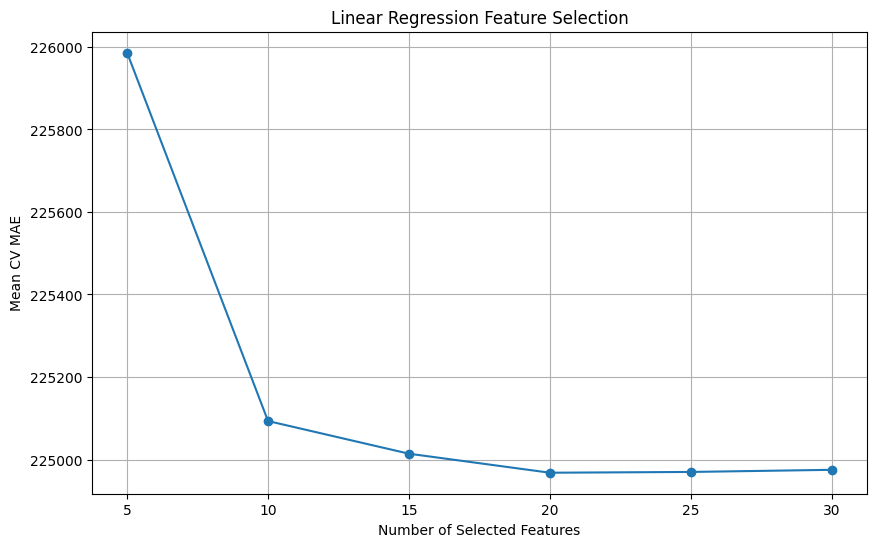

Best number of features: 20
Mean CV MAE: 224968.0497652001
Std CV MAE: 2479.270546535148


In [87]:
# Use the dataset from part 3
X_train_linear = X_train.copy()

total_rooms_train = X_train_linear["bedroomcnt"] + X_train_linear["bathroomcnt"]

X_train_linear["sqft_per_room"] = (
    X_train_linear["calculatedfinishedsquarefeet"] /
    total_rooms_train.replace(0, np.nan)
)

sqft_per_room_median = X_train_linear["sqft_per_room"].median()
X_train_linear["sqft_per_room"] = X_train_linear["sqft_per_room"].fillna(sqft_per_room_median)

#tune the number of selected features for linear regression using sequential feature selection and cross-validation
feature_counts = [5, 10, 15, 20, 25, 30]

results = []

for k in feature_counts:

    selector = SequentialFeatureSelector(
        estimator=LinearRegression(),
        n_features_to_select=k,
        direction="forward",
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1
    )

    selector.fit(X_train_linear, y_train)

    selected = X_train_linear.columns[selector.get_support()]

    X_selected = X_train_linear[selected]

    scores = -cross_val_score(
        LinearRegression(),
        X_selected,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=RepeatedKFold(n_splits=5, n_repeats=5, random_state=42),
        n_jobs=-1
    )

    results.append({
        "Features": k,
        "Mean CV MAE": scores.mean(),
        "Std CV MAE": scores.std()
    })

tuning_results = pd.DataFrame(results)
tuning_results

#plot the results of the tuning experiment
plt.figure(figsize=(10, 6))
plt.plot(
    tuning_results["Features"],
    tuning_results["Mean CV MAE"],
    marker="o"
)

plt.xlabel("Number of Selected Features")
plt.ylabel("Mean CV MAE")
plt.title("Linear Regression Feature Selection")

plt.grid(True)

plt.show()

#train the final linear regression model with the best number of features
best_k = tuning_results.loc[
    tuning_results["Mean CV MAE"].idxmin(),
    "Features"
]

print("Best number of features:", best_k)

best_selector = SequentialFeatureSelector(
    estimator=LinearRegression(),
    n_features_to_select=best_k,
    direction="forward",
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)
best_selector.fit(X_train_linear, y_train)
best_features = X_train_linear.columns[best_selector.get_support()]
X_best = X_train_linear[best_features]

#evaluate the final model using cross-validation
final_scores = -cross_val_score(
    LinearRegression(),
    X_best,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=RepeatedKFold(
        n_splits=5,
        n_repeats=5,
        random_state=42
    ),
    n_jobs=-1
)

print("Mean CV MAE:", final_scores.mean())
print("Std CV MAE:", final_scores.std())

### 4.B Discussion

Answer the following questions.

#### 4.B.1

Which hyperparameters had the greatest impact on model performance? Briefly explain.

- **Random Forest:**

The hyperparameter with the greatest impact was `max_features`. Using fewer features at each split clearly reduced the cross-validation MAE. The `max_depth` and `min_samples_leaf` parameters also affected performance by controlling the complexity of the trees.

In comparison, changing `min_samples_split` and `n_estimators` produced only small improvements after the model reached a performance plateau.

- **HistGradientBoosting:**

The hyperparameter with the greatest impact was `max_leaf_nodes`. Increasing the number of leaf nodes produced the largest reduction in the cross-validation MAE. The `min_samples_leaf` parameter also improved performance by controlling the number of observations required in each leaf.

In comparison, changing `max_features` produced only a small improvement, while changing `max_iter` and `max_depth` alone did not improve the validation MAE.     

- **Linear Regression:**   

the most influential tuning decision was the number of features selected during forward feature selection. Since ordinary Linear Regression has very few meaningful hyperparameters, feature selection had the greatest effect on controlling model performance. Selecting too few features removed useful information, while selecting too many features added complexity without providing meaningful improvements. Based on the validation results, performance reached a plateau after approximately 20 features, so we selected the smallest number of features within that plateau to maintain a simpler model.


#### 4.B.2

Did hyperparameter tuning substantially improve the performance of all three models, or only some of them?

- **Random Forest:**   

hyperparameter tuning produced a modest improvement. The mean CV MAE decreased from 188,559.74 in Part 3 to 184,632.86 after tuning, which was an improvement of about 3,927, or 2.1%. 

- **HistGradientBoosting:**

Hyperparameter tuning produced a modest improvement in performance. The mean CV MAE decreased from about $191,285.87 for the baseline model to $188,100.10 for the tuned model. This was an improvement of about $3,185.77, or approximately 1.7%.
The CV standard deviation also decreased slightly, from about $3,186.69 to $3,150.47. Overall, tuning improved the model.  

- **Linear Regression:**   

tuning produced a modest improvement rather than a substantial change in performance. Most of the improvement came from the feature engineering and feature selection steps completed in earlier parts of the project. The tuning process mainly helped identify a more efficient feature set and avoid including unnecessary variables. (In comparison, the tree-based models had more opportunities for improvement because they have more impactful hyperparameters to optimize).

#### 4.B.3

Which tuning method(s) did you use for each model? Briefly explain why you chose those methods.

- **Random Forest:**

We first used one-parameter sweeps to examine the main Random Forest hyperparameters and identify promising ranges or performance plateaus. We used a smaller number of cross-validation repeats during the early sweeps to reduce runtime.

We then performed focused sweeps over narrower ranges. This allowed us to evaluate more values near the best-performing regions without testing many unnecessary combinations.

Because Random Forest has several hyperparameters that may interact with each other, we also used `RandomizedSearchCV` to test different combinations from the promising ranges. We chose Randomized Search instead of a full Grid Search because it could explore many combinations with a lower computational cost.

Finally, we compared the best focused-sweep model with the best `RandomizedSearchCV` model using the same repeated 5-fold cross-validation with 5 repeats. This provided a fair and more reliable final comparison.  

The focused-sweep model performed slightly better than the `RandomizedSearchCV` model. Their results were almost identical, but the focused sweep had a slightly lower mean CV MAE, so we kept the focused-sweep parameters for the final Random Forest model.

- **HistGradientBoosting:**

We started with the default value for each hyperparameter and then tested each one separately over a wide range. We used a smaller number of cross-validation repeats during the early sweeps to reduce runtime. A random seed of 42 was used for all cross-validation steps to keep the comparisons consistent.

After identifying promising values, we gradually narrowed the ranges and reduced the step sizes. This allowed us to examine the strongest areas more closely without testing too many unnecessary values.

The selected parameter values were then added to the model and kept during the later tuning steps. We also tested each tuned hyperparameter individually while keeping the other hyperparameters at their default values. This helped us understand the effect of each parameter on model performance.

We then used `RandomizedSearchCV` around the promising ranges found during the sweeps. This allowed us to test different combinations of hyperparameters and examine possible interactions between them. Finally, we compared the best focused-sweep model and the best `RandomizedSearchCV` model using the same cross-validation setup.

`RandomizedSearchCV` performed better than the focused sweeps under the same cross-validation setup. Therefore, we kept the parameters found by `RandomizedSearchCV` for the final HistGradientBoosting model. Although its variation across the folds was slightly higher, its lower mean CV MAE made it the better final choice.

- **Linear Regression:**

We used a validation curve by testing several values for the number of selected features using Sequential Feature Selection. This method was chosen because ordinary Linear Regression has limited hyperparameters that meaningfully affect its performance.

Evaluating different feature subset sizes allowed us to examine whether adding more features improved the model or only increased its complexity. We selected a feature count near the beginning of the performance plateau to balance predictive performance and model simplicity.


#### 4.B.4

After tuning, how did the relative performance of your three models change? Did tuning affect which model appeared to perform best?

- **Random Forest:**

After tuning, the mean CV MAE decreased from approximately $188,553.66 to $184,632.86, an improvement of about $3,920.80, or 2.1%. Although the CV standard deviation increased slightly from $2,605.80 to $2,883.61, Random Forest still achieved the lowest mean CV MAE among the three models.

- **HistGradientBoosting:**

After tuning, the mean CV MAE decreased from approximately $191,285.87 to $188,100.10, an improvement of about $3,185.77, or 1.7%. The CV standard deviation also decreased slightly from $3,186.69 to $3,150.47. HistGradientBoosting therefore improved after tuning, but it remained the second-best model behind Random Forest.

- **Linear Regression:**    

Linear Regression showed a small improvement after selecting an optimized feature subset. The tuning process improved the efficiency and performance of Linear Regression.

**Overall**, tuning improved the performance of both tree-based models, but it did not change their relative ranking or which model performed best. Random Forest was the best-performing model before tuning and remained the best model after tuning. The difference between Random Forest and HistGradientBoosting also became slightly larger after tuning. The difference in mean CV MAE increased from approximately $2,732 before tuning to $3,467 after tuning. Therefore, tuning made Random Forest a stronger choice as the final model.

## Part 5: Final Model and Workflow Assessment [14 pts]

### 5.A Coding

Using the work completed in **Parts 1–4**:

Select your **best-performing model** and prepare your final modeling pipeline.

Your pipeline should include all preprocessing, feature engineering, feature selection, and hyperparameter tuning decisions that you chose to retain.

Evaluate your final model by:

* Training on the complete training dataset.
* Reporting the **mean** and **standard deviation** of the repeated cross-validation MAE.
* Evaluating the model on the held-out test set.
* Reporting the final test MAE.

### Final Random Forest Pipeline

We selected the tuned Random Forest as the final model because it achieved the lowest mean cross-validation MAE in Parts 1–4. The input datasets were saved after the initial cleaning and retained feature engineering completed in Milestone 1, including the creation of `property_age`.

The final pipeline performs all remaining preprocessing steps. It converts `hashottuborspa`, `poolcnt`, and `taxdelinquencyflag` into binary indicators based on whether a value is present. Missing values in `buildingqualitytypeid`, `unitcnt`, and `lotsizesquarefeet` are imputed using the training median. Missing values in `heatingorsystemtypeid` are replaced with `"Unknown"` before one-hot encoding.

The pipeline applies target encoding to the high-cardinality features `regionidcity` and `regionidzip`, and one-hot encoding to `fips`, `propertylandusetypeid`, and `heatingorsystemtypeid`. After preprocessing, a Random Forest feature selector retains the 20 features with the highest importance scores. The tuned Random Forest is then fitted using the hyperparameters selected in Part 4.

We evaluated the complete pipeline using repeated 5-fold cross-validation with 5 repeats. Finally, we trained the pipeline on the complete training dataset and evaluated it on the held-out test set.

In [3]:
# Load the train and test sets saved before imputation and encoding in milestone 1 (after first cleaning)
X_train_input = pd.read_csv("X_train.csv")
X_test_input = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_test = pd.read_csv("y_test.csv").squeeze("columns")

print("X_train_input shape:", X_train_input.shape)
print("X_test_input shape:", X_test_input.shape)

print("\nMissing values in the training data:")
display(X_train_input.isna().sum().loc[lambda x: x > 0].sort_values(ascending=False))

print("Target shapes:")
print(y_train.shape)
print(y_test.shape)

X_train_input shape: (60664, 17)
X_test_input shape: (15167, 17)

Missing values in the training data:


hashottuborspa           59500
taxdelinquencyflag       58368
poolcnt                  48048
heatingorsystemtypeid    21844
buildingqualitytypeid    21651
unitcnt                  20966
lotsizesquarefeet         6448
dtype: int64

Target shapes:
(60664,)
(15167,)


In [ ]:
# Define functions to convert columns to appropriate types
def convert_to_indicator(X): return X.notna().astype(int)
def convert_to_object(X): return X.astype("object")
def convert_to_string(X): return X.astype(str)

# Define the column groups for different preprocessing strategies
indicator_cols = ["hashottuborspa", "poolcnt", "taxdelinquencyflag"]
median_cols = ["buildingqualitytypeid", "unitcnt", "lotsizesquarefeet"]
target_encode_cols = ["regionidcity", "regionidzip"]
one_hot_cols = ["fips", "propertylandusetypeid"]
heating_col = ["heatingorsystemtypeid"]

In [ ]:
# Define transformers for each type of preprocessing

# indicator_transformer: Converts specified columns to binary indicators (1 if not null, 0 if null)
indicator_transformer = FunctionTransformer(convert_to_indicator, feature_names_out="one-to-one")

# median_transformer: Imputes missing values in specified columns with the median of each column
median_transformer = SimpleImputer(strategy="median")

# target_encoding_transformer: Converts specified columns to string type and applies target encoding for continuous targets
target_encoding_transformer = Pipeline([
    ("to_string", FunctionTransformer(convert_to_string, feature_names_out="one-to-one")),
    ("target_encoder", TargetEncoder(target_type="continuous", smooth=50, cv=5, shuffle=True, random_state=42))
])

# one_hot_transformer: Converts specified columns to string type and applies one-hot encoding, ignoring unknown categories
one_hot_transformer = Pipeline([
    ("to_string", FunctionTransformer(convert_to_string, feature_names_out="one-to-one")),
    ("one_hot_encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# heating_transformer: Converts specified columns to object type, imputes missing values with "Unknown", converts to string type, and applies one-hot encoding, ignoring unknown categories
heating_transformer = Pipeline([
    ("to_object", FunctionTransformer(convert_to_object, feature_names_out="one-to-one")),
    ("unknown_imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("to_string", FunctionTransformer(convert_to_string, feature_names_out="one-to-one")),
    ("one_hot_encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine all transformers into a single ColumnTransformer
preprocessor = ColumnTransformer([
    ("indicator", indicator_transformer, indicator_cols),
    ("median", median_transformer, median_cols),
    ("target_encoding", target_encoding_transformer, target_encode_cols),
    ("one_hot", one_hot_transformer, one_hot_cols),
    ("heating", heating_transformer, heating_col)
], remainder="passthrough", verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")

,transformers,"[('indicator', ...), ('median', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,func,<function con...0016ED800C5E0>
,inverse_func,None
,validate,False


In [6]:
# Store the final Random Forest hyperparameters selected in Part 4
final_rf_params = {
    "n_estimators": 900,
    "max_depth": 20,
    "min_samples_leaf": 2,
    "max_features": 4,
    "min_samples_split": 8,
    "random_state": 42,
    "n_jobs": -1
}

# Feature selection using the Random Forest model important features. We will select the top 20 features based on their importance scores.
feature_selector = SelectFromModel( RandomForestRegressor(random_state=42, n_jobs=-1),threshold=-float("inf"),max_features=20)

# Build the final end-to-end pipeline:
# 1. Impute and encode the input features
# 2. Feature selection using the Random Forest model
# 3. Fit the tuned Random Forest model
final_rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", feature_selector),
    ("model", RandomForestRegressor(**final_rf_params))
])

# Evaluate the final pipeline using repeated 5-fold cross-validation
final_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
final_cv_scores = -cross_val_score(final_rf_pipeline,X_train_input,y_train,scoring="neg_mean_absolute_error",cv=final_cv,n_jobs= 1)

final_mean_cv_mae = final_cv_scores.mean()
final_std_cv_mae = final_cv_scores.std()

print(f"Mean CV MAE: {final_mean_cv_mae:.6f}")
print(f"CV MAE Standard Deviation: {final_std_cv_mae:.6f}")

Mean CV MAE: 184958.921574
CV MAE Standard Deviation: 2883.356713


In [9]:
# Fit the complete pipeline on the full training dataset
final_rf_pipeline.fit(X_train_input, y_train)

# Generate predictions for the training and held-out test sets
final_train_predictions = final_rf_pipeline.predict(X_train_input)
final_test_predictions = final_rf_pipeline.predict(X_test_input)

# Calculate the final training and test MAE
final_train_mae = mean_absolute_error(y_train, final_train_predictions)
final_test_mae = mean_absolute_error(y_test, final_test_predictions)

# Report the final model performance
print(f"Train MAE: {final_train_mae:.6f}")
print(f"Mean CV MAE: {final_mean_cv_mae:.6f}")
print(f"CV MAE Standard Deviation: {final_std_cv_mae:.6f}")
print(f"Test MAE: {final_test_mae:.6f}")

Train MAE: 144746.077572
Mean CV MAE: 184958.921574
CV MAE Standard Deviation: 2883.356713
Test MAE: 185579.648795


In [10]:
# Summarize the final model results
final_model_results = pd.DataFrame([{
    "Final Model": "Tuned Random Forest",
    "Selected Features": 20,
    "Train MAE": final_train_mae,
    "Mean CV MAE": final_mean_cv_mae,
    "CV MAE Standard Deviation": final_std_cv_mae,
    "Test MAE": final_test_mae
}])

final_model_results

,Final Model,Selected Features,Train MAE,Mean CV MAE,CV MAE Standard Deviation,Test MAE
0,Tuned Random Forest,20,144746.077572,184958.921574,2883.356713,185579.648795


The final test MAE was close to the repeated cross-validation MAE, indicating that the complete workflow, including imputation, encoding, feature selection, and model fitting, generalized consistently to the held-out test data.

### 5.B Discussion

Answer the following questions.

#### 5.B.1

Compare the performance of your final model with its original baseline from **Part 1**. Which changes contributed the most to the improvement?

The original Random Forest baseline in Part 1 had a mean cross-validation MAE of $188,553.66 with a standard deviation of $2,605.80. The final Random Forest pipeline reduced the mean CV MAE to $184,958.92, an improvement of about $3,594.74, or 1.91%. Its held-out test MAE was $185,579.65, which was close to the cross-validation result and showed that the final model generalized consistently to unseen data.

The final model also showed less overfitting. The baseline training MAE was $69,954.16, creating a train-validation gap of about $118,599.50. The final training MAE increased to $144,746.08, but the train-validation gap decreased to about $40,212.84. This suggests that the tuned model gave up some training-set accuracy in exchange for better performance on unseen data.

Hyperparameter tuning contributed the most to the improvement. The final settings limited tree complexity and required more observations for splits and leaves, which reduced overfitting. The feature engineering experiments from Part 2 were not retained because none improved Random Forest performance. Feature selection also did not directly reduce the CV MAE, but it reduced the feature set from 41 to 20 while maintaining similar performance. Therefore, feature selection mainly simplified the model, while hyperparameter tuning produced the main improvement in predictive performance.

Placing imputation, encoding, and feature selection inside the pipeline also reduced the risk of data leakage. During cross-validation, these steps were fitted only on the training portion of each fold and then applied to the validation portion. The internal cross-fitting used by the Target Encoder also prevented each training row from being encoded directly with its own target value.

#### 5.B.2

Looking back at the hypotheses you proposed in **Milestone 1**, which were supported by your experimental results? Were any hypotheses disproved?

Our results partly supported the hypotheses from Milestone 1.  
The strongest support was for creating ratio features from related property-size variables. In particular, `sqft_per_room` was useful for Linear Regression and was kept during feature selection. This suggests that comparing living area with the number of rooms gave the linear model information that was easier to use than the original features by themselves.

However, the other engineered features, such as `total_rooms`, `living_lot_ratio`, and `age_quality_interaction`, did not consistently improve the cross-validation MAE. This means that combining related property features did not help every model. Random Forest and HistGradientBoosting showed very little improvement from these new features. A likely reason is that tree-based models can already learn nonlinear patterns and interactions from the original features without needing us to create them manually.

The results did not support the broader hypothesis that all reasonable feature combinations would improve prediction. Only `sqft_per_room` showed enough value to be kept for Linear Regression. None of the engineered features were kept for the final Random Forest model because they did not improve its validation performance.

Overall, the experiments showed that feature engineering was more useful for Linear Regression than for the tree-based models. Linear Regression benefited from a feature that directly described the relationship between property size and number of rooms. In contrast, Random Forest and HistGradientBoosting were already able to learn many of these relationships from the original data. Therefore, the value of a new feature depended on the type of model, and feature engineering did not improve all models in the same way.

#### 5.B.3

Why did you select this model as your final model? Discuss both its predictive performance and any other considerations (such as stability, simplicity, or interpretability).

- We selected the tuned Random Forest as the final model because it gave the best overall predictive performance. Its mean cross-validation MAE was $184,958.92, which was lower than the results for HistGradientBoosting and Linear Regression. Its test MAE was $185,579.65, which was very close to the cross-validation result. This small difference shows that the model performed consistently on unseen data and that the cross-validation result was a reliable estimate of its final performance.

- The model was also stable across the repeated cross-validation runs. The standard deviation of the CV MAE was $2,883.36, which was small compared with the mean MAE. This means that the model produced similar results across different training and validation splits. Hyperparameter tuning also reduced overfitting. The final training MAE was $144,746.08, and the gap between the training and validation MAE was much smaller than the gap for the original Random Forest baseline.

- Random Forest was also a good choice for this housing dataset because property values can depend on complex and nonlinear relationships. For example, the effect of living area may change based on location, property age, land use, or building quality. Random Forest can learn these relationships and interactions without requiring us to define them manually. This may explain why the manually engineered features added little improvement to the tree-based models. The model also does not require feature scaling and can work well with a combination of continuous, binary, and encoded categorical features.

- Another advantage is that Random Forest combines predictions from many decision trees. A single decision tree can change greatly when the training data changes, but averaging many trees usually produces more stable predictions and reduces the variance of the model. Our final model used 900 trees, while parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf` controlled the complexity of the individual trees and helped reduce overfitting.

- Feature selection was another useful consideration. We reduced the number of model inputs from 41 to 20 while keeping strong predictive performance. This removed features that added little value, reduced model complexity, and made the final model easier to review. Random Forest is not as directly interpretable as Linear Regression because it does not provide one simple coefficient for each feature. However, it still provides feature importance scores, which can help us identify the property characteristics that contributed most to the predictions.

- The final pipeline also made the complete workflow more reliable and easier to reuse. It included missing-value imputation, categorical encoding, feature selection, and model fitting in one process. Overall, the tuned Random Forest gave the best balance of accuracy, stability, flexibility, and model complexity. It produced the lowest validation error, performed consistently on the test set, handled complex relationships in the housing data, and maintained strong performance with a smaller set of features.

#### 5.B.4

What did you learn about your dataset and the machine learning process through this end-to-end modeling workflow? If you had additional time, what would you investigate next?

- This end-to-end workflow showed us that the Zillow dataset contains different types of information, and each type needs a different preprocessing method. Some missing values showed that a property feature, such as a pool or hot tub, was not present. Other missing values represented unknown information and needed median imputation or a new category. We also learned that location variables were important but difficult to prepare because city and ZIP code had many categories. Target encoding helped us keep this useful information without creating a very large number of one-hot encoded columns.

- We also learned that a feature that makes logical sense does not always improve model performance. Features such as `total_rooms`, `living_lot_ratio`, and `age_quality_interaction` seemed useful, but they did not consistently reduce the cross-validation MAE. The `sqft_per_room` feature was more helpful for Linear Regression, but it did not improve the final Random Forest model. This showed us that the value of feature engineering depends on the model. Linear models may benefit from manually created relationships, while tree-based models can often learn nonlinear relationships and interactions from the original features.

- The modeling process also showed us why training performance alone is not enough for selecting a model. The baseline Random Forest had a very low training MAE, but its much larger validation MAE showed that it was overfitting. Repeated cross-validation gave us a more reliable way to compare models across different data splits. Hyperparameter tuning produced the largest improvement because it controlled the depth and complexity of the trees. Feature selection did not greatly reduce the MAE, but it reduced the number of inputs from 41 to 20 while keeping similar performance.

- Another important lesson was the value of using one complete pipeline. Imputation, encoding, feature selection, and model training were fitted only on the training portion of each cross-validation fold. This reduced the risk of data leakage and made the evaluation more realistic. The close values of the final cross-validation MAE and test MAE also showed that the pipeline performed consistently on unseen data.

- With additional time, we would first examine the prediction errors in more detail. We would compare errors across different property-value ranges, cities, ZIP codes, and property types. This could show whether the model has more difficulty with expensive properties, rare property types, or locations with fewer observations.

- We would also investigate more ways to use the location columns. One option would be to apply K-means clustering to scaled latitude and longitude values and create a `location_cluster` feature. This could group nearby properties into smaller geographic areas, even when they have different city or ZIP code labels. We would keep the original latitude and longitude features because they may still contain useful detailed location information.

- K-nearest neighbors could also be tested for location-related missing values. For example, the latitude and longitude of nearby properties could be used to estimate a missing city, neighborhood, or ZIP code. Another option would be to divide the map into geographic sections using grid cells, geohashes, or census-based areas. These methods could represent smaller local housing markets more clearly than broad city or county categories.

- We could also create distance-based features, such as the distance from a property to a city center or another important area. In addition, we would compare target encoding with other methods, such as frequency encoding or geographic grouping, for high-cardinality location columns. Any target-based location feature would need to be created inside cross-validation to avoid data leakage.

- Finally, we would test other models that can handle categorical variables directly, such as CatBoost, and compare them with the final Random Forest. We would also use permutation importance or SHAP values to better understand how location, property size, age, quality, and other features affect the predictions.